<a href="https://colab.research.google.com/github/episode16/Py/blob/master/test/test_okkam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Тестовое задание в Okkam

## Основная задача: построить регрессионную модель предсказания зависимой величины с помощью предоставленных факторов. Подзадачи:

In [578]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [579]:
!gdown 1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI


Downloading...
From (original): https://drive.google.com/uc?id=1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI
From (redirected): https://docs.google.com/spreadsheets/d/1-Y7YeW8JD49843va8WjxdLQwfEGQQ6uHPJ9WA-UtWhI/export?format=xlsx
To: /content/data_for_test.xlsx
33.6kB [00:00, 44.2MB/s]


### a) провести разведочный анализ данных (описательные статистики, распределения, сводные таблицы, графики), среди графиков желателен график динамики целевой величины с отметками периодов рекламной активности; содержательно описать результаты анализа;

In [580]:
df = pd.read_excel('./data_for_test.xlsx', 'Raw data', index_col=None)
df.to_csv('data_for_test.csv', encoding='utf-8')

description_data = pd.read_excel('./data_for_test.xlsx', 'Data description', index_col=None)
description_data.to_csv('data_for_test.csv', encoding='utf-8')
description_data

,Наименование фактора,Описание фактора (единицы измерения)
0,Date,Дата (дни с 1 января 2013 года по 1 февраля 20...
1,Y,Целевой показатель - суммарное количество теле...
2,TV,Показатель медиа активности на национальном те...
3,OOH,OTS по наружной рекламе - оценка числа контакт...
4,Seasonal_Sales,Нормированная в шкалу от 0 (минимум) до 1 (мак...
5,usd_rate,Курс доллара по Yahoo Finance (рублей за 1 дол...


In [581]:
print(df.info())

print(f"\nfirst 3 lines in df:\n{df.head(3)}")

print(f"\nNaNs in table:\n{df.isna().sum()}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            762 non-null    datetime64[ns]
 1   Y               759 non-null    float64       
 2   TV              762 non-null    int64         
 3   OOH             762 non-null    float64       
 4   Seasonal_Sales  762 non-null    float64       
 5   Usd_rate        762 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 35.8 KB
None

first 3 lines in df:
        Date     Y  TV  OOH  Seasonal_Sales   Usd_rate
0 2013-01-01   NaN   0  0.0        0.060802  30.502001
1 2013-01-02   0.0   0  0.0        0.060802  30.337200
2 2013-01-03  17.0   0  0.0        0.060802  30.156500

NaNs in table:
Date              0
Y                 3
TV                0
OOH               0
Seasonal_Sales    0
Usd_rate          0
dtype: int64



Видим, что 3 значения Y пропущено. Глядя на сам датасет, отсутсвуют 3 дня из 2 лет, или 0.4% данных со всего датасета.

In [582]:
df = df.dropna(subset=['Y'])

In [583]:
df.sample(5)

,Date,Y,TV,OOH,Seasonal_Sales,Usd_rate
531,2014-06-16,19.0,0,0.0,0.360011,34.593102
524,2014-06-09,15.0,0,0.0,0.360011,34.293201
167,2013-06-17,22.0,0,0.0,0.360011,31.723700
8,2013-01-09,19.0,0,0.0,0.060802,30.274500
20,2013-01-21,15.0,0,0.0,0.060802,30.239500


### Разведочный анализ

Основные метрики каждого признака

In [584]:
df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
Date,759,2014-01-16 13:28:13.280632320,2013-01-02 00:00:00,2013-07-10 12:00:00,2014-01-17 00:00:00,2014-07-25 12:00:00,2015-02-01 00:00:00,NaN
Y,759.0,23.627141,0.0,16.0,21.0,27.0,176.0,15.08155
TV,759.0,1044.12253,0.0,0.0,0.0,0.0,26310.0,3652.305315
OOH,759.0,470.498024,0.0,0.0,0.0,0.0,145137.0,6220.595044
Seasonal_Sales,759.0,0.461595,0.0,0.062488,0.360924,0.7597,1.0,0.352874
Usd_rate,759.0,36.311265,29.883301,32.113201,33.4133,36.031149,68.735001,7.98544


Описательная статистика:
- Целевая переменная Y (звонки) имеет среднее значение ~23.6 и широкий разброс (от 0 до 176) и стандартное отклонение 15
- Медиаактивность (TV) в среднем ~1040 контакта (тыс.), но с большими колебаниями (до 26310).
- Наружная реклама (OOH) в среднем ~467 контактов (тыс.), но часто равна 0 (медиана 0).
- Сезонность продаж колеблется от 0.06 до 0.94 (нормировано).
- Курс доллара варьируется от 29.88 до 68.73 руб.

### Анализ целевой переменной Y

value counts:
Y
18.0     44
20.0     41
15.0     40
23.0     40
21.0     39
         ..
105.0     1
133.0     1
90.0      1
83.0      1
51.0      1
Name: count, Length: 76, dtype: int64

Mean rate: 23.627140974967062

Median rate: 21.0


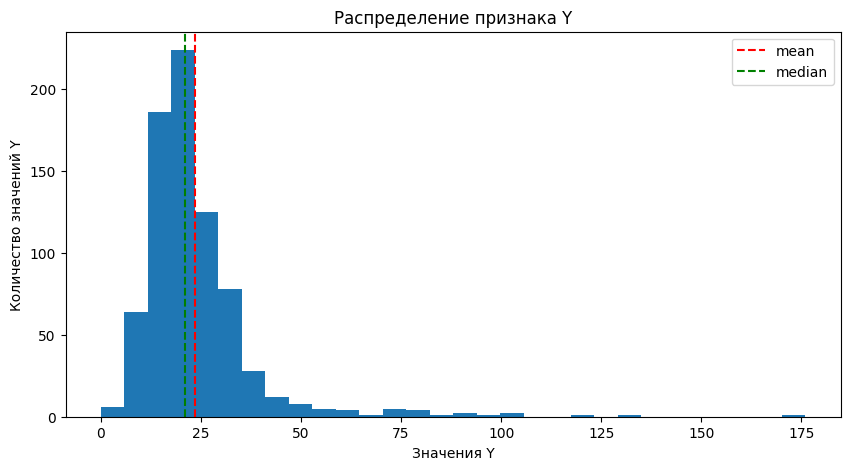

In [585]:
print(f"value counts:\n{df['Y'].value_counts()}")

plt.figure(figsize=(10, 5))
plt.hist(df['Y'], bins=30)
plt.title('Распределение признака Y')
plt.xlabel('Значения Y')
plt.ylabel('Количество значений Y')
mean_Y = df['Y'].mean()
median_Y = df['Y'].median()
plt.axvline(x=mean_Y , color='r', linestyle='--', label='mean')
plt.axvline(x=median_Y, color='g', linestyle='--', label='median')
print(f'\nMean rate: {mean_Y}')
print(f'\nMedian rate: {median_Y}')
plt.legend()
plt.show()

Глядя на график распределения Y, можно сказать, что:
- Распределение асимметрично — наблюдается правосторонний (положительный) перекос: основная масса значений сосредоточена в пределах 15–30, при этом хвост распределения тянется далеко вправо.
- Среднее значение Y превышает медиану, что подтверждает наличие положительной асимметрии: среднее: ~23.6 и медиана: ~21.0

### Анализ остальных признаков
#### Распределения остальных признаков


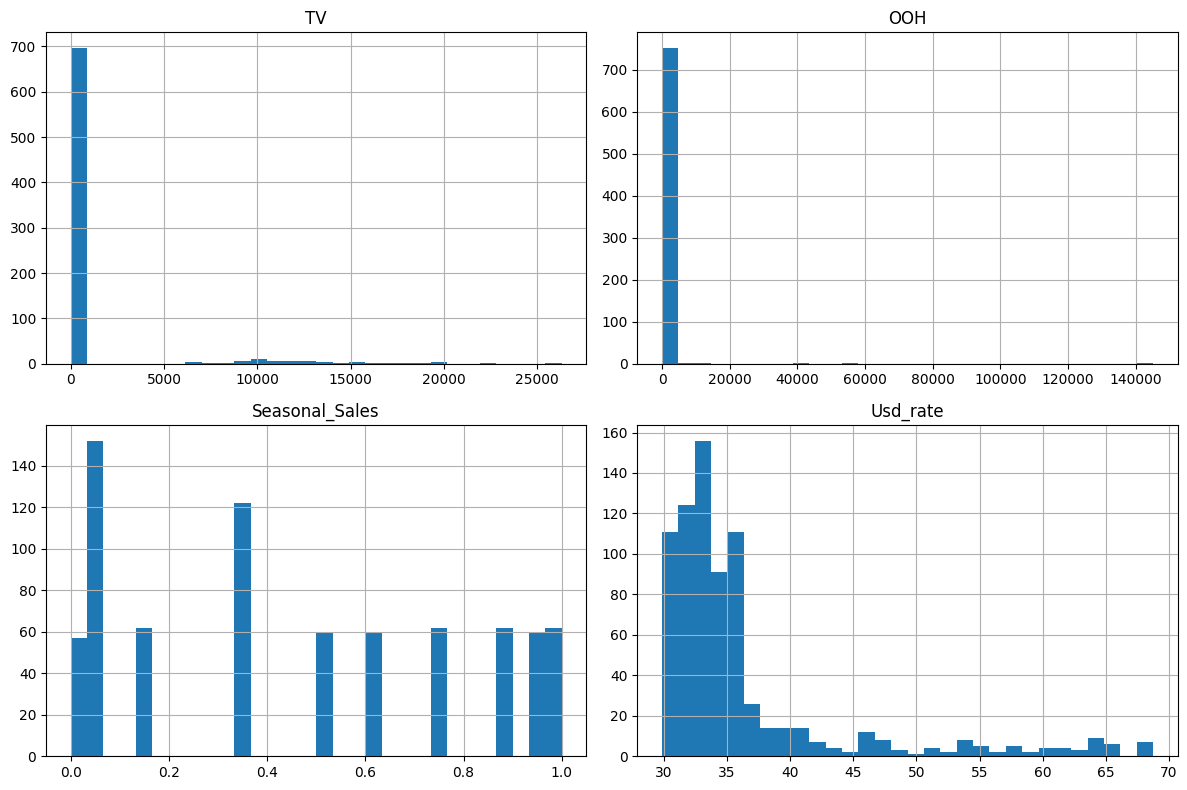

In [586]:
import seaborn as sns

numeric_cols = ['Y', 'TV', 'OOH', 'Seasonal_Sales', 'Usd_rate']
df[numeric_cols[1:]].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

На данных гистограммах заметим, что:
- TV:
    - Распределение крайне смещено влево, основная масса значений — в районе 0, значит, TV-реклама запускалась редко
    - Длинный правый хвост: вероятно, редкие, рекламные кампании
- ООН:
    - Идентично с распределением TV
- Seasonal_sales:
    - Значения распределены по кластерам
    - Есть ступенчатость, что указывает на дискретность
- Usd_rate:
    - Большинство значений сконцентрировано в области 30-36, далее заметем хвост -> датасет ограничен по дате, где значения звонков сосредоточены в период, когда usd ~ 30-40

#### График динамики целевой величины с рекламной активностью

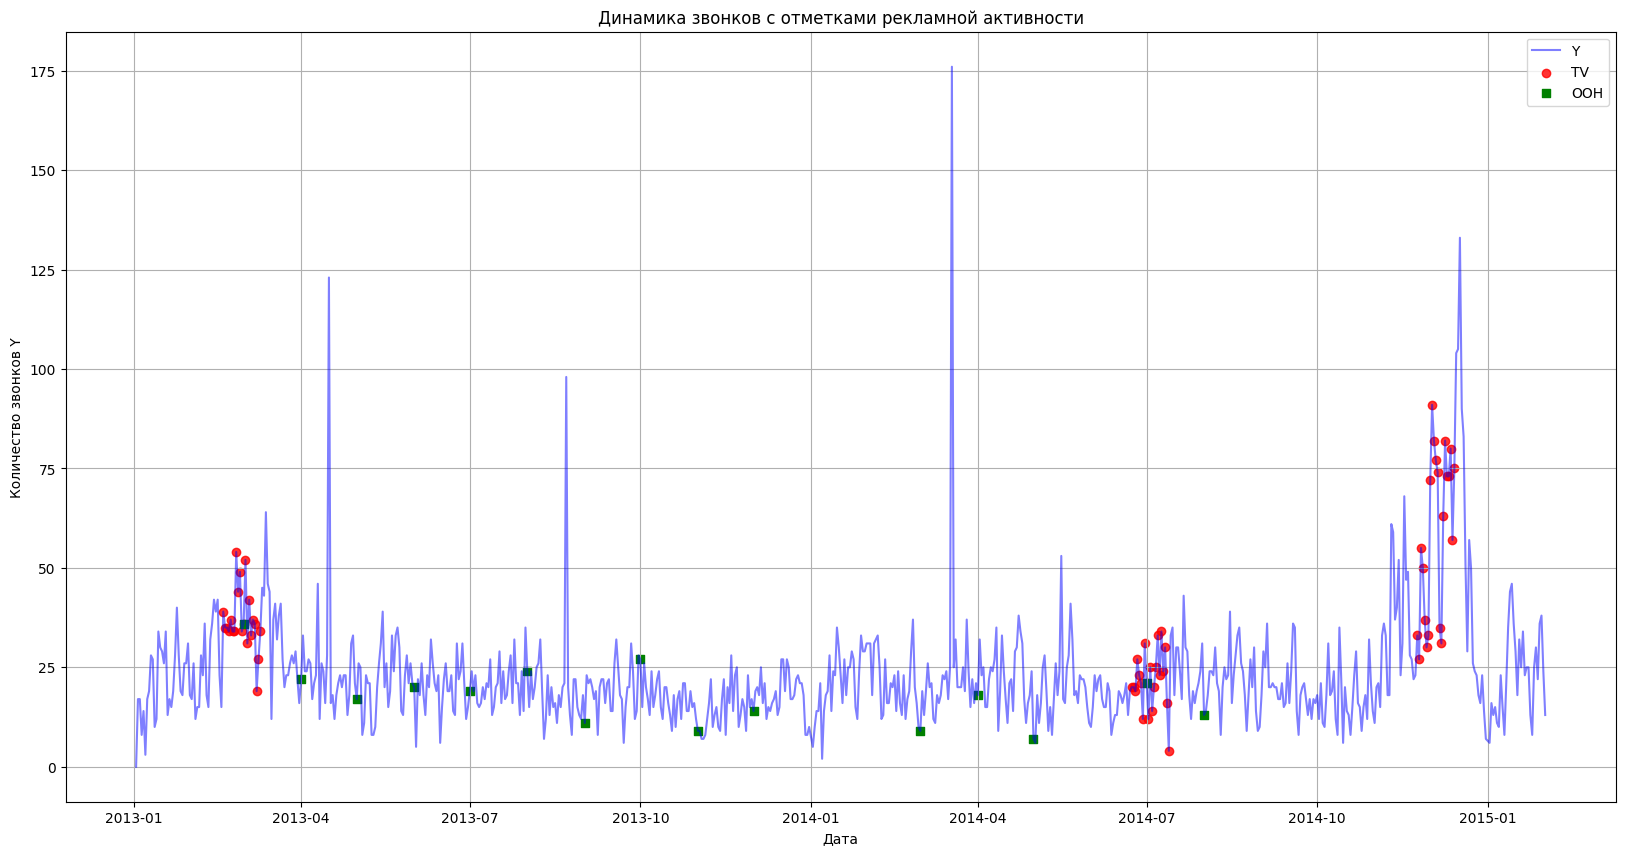

In [587]:
plt.figure(figsize=(20, 10))
plt.plot(df['Date'], df['Y'], label='Y', color='blue', alpha = 0.5)

tv_active = df[df['TV'] > 0]
plt.scatter(tv_active['Date'], tv_active['Y'], color='red',
            marker='o', label='TV', alpha=0.8)

ooh_active = df[df['OOH'] > 0]
plt.scatter(ooh_active['Date'], ooh_active['Y'], color='green',
            marker='s', label='OOH', alpha=1)

plt.title('Динамика звонков с отметками рекламной активности')
plt.xlabel('Дата')
plt.ylabel('Количество звонков Y')
plt.legend()
plt.grid()
plt.show()

- Красные (TV) и зелёные (OOH) маркеры не совпадают с устойчивыми всплесками звонков (за исключением конца 2014 - наблюдается пик звонков после рекламной кампании на TV). Это может означать, что:

    - Реклама неэффективна в привлечении звонков.

    - Её влияние слишком слабое на фоне других факторов (например, сезонность, конкуренция, экономическая ситуация).


In [588]:
df['TV_active'] = df['TV'] > 0
pd.pivot_table(df, values='Y', columns= 'TV_active', aggfunc=['mean', 'count'])

mean            count      
TV_active      False      True  False True 
Y          22.231322  39.047619   696    63

В дни, когда нет рекламы:
количество звонков ~ 22
количество дней: 696

В дни, когда есть реклама:
количество звонков ~ 39
количество дней: 63

### Вывод:
- Реклама на ТВ влияет на количество звонков, но не так сильно. К примеру, на момент апреля 2013 и 2014 года, а также на момент ~августа 2013 нет зависимости звонков от рекламы TV или ООН

In [589]:
df['OOH_active'] = df['OOH'] > 0
pd.pivot_table(df, values='Y', columns= 'OOH_active', aggfunc=['mean', 'count'])

mean       count      
OOH_active      False True  False True 
Y           23.744624  17.8   744    15

В дни, когда нет рекламы:
количество звонков ~ 23
количество дней: 744

В дни, когда есть реклама:
количество звонков ~ 17
количество дней: 15


Также попробуем создать новый признак, основанный на дате - dayofweek - workday/weekend

In [590]:
df['dayofweek'] = df['Date'].dt.dayofweek
print(df['dayofweek'].value_counts())

dayofweek
4    109
6    109
5    109
3    108
2    108
0    108
1    108
Name: count, dtype: int64


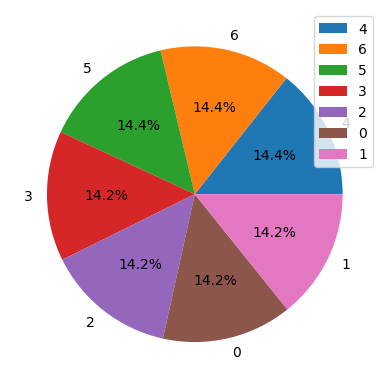

In [591]:
data = df['dayofweek'].value_counts()
plt.pie(data.values, labels = data.index, autopct = '%1.1f%%')
plt.legend()
plt.show()

Date
0    2790.0
1    3043.0
2    2863.0
3    2859.0
4    2601.0
5    1948.0
6    1829.0
Name: Y, dtype: float64


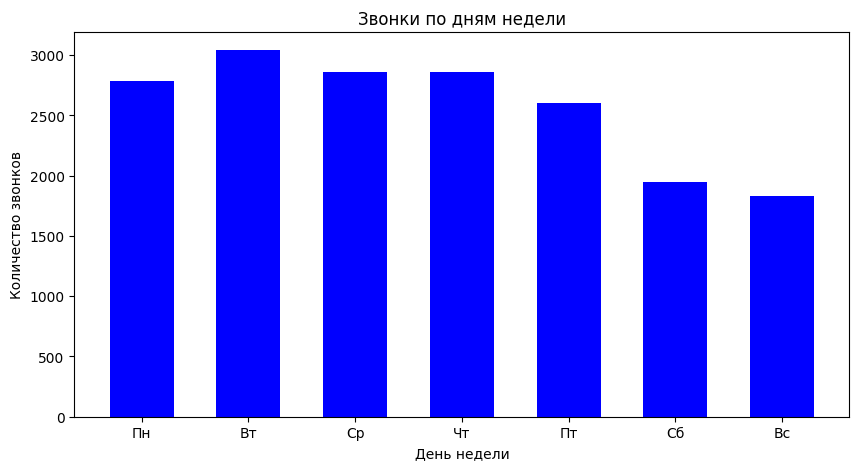

In [592]:
calls_by_day = df.groupby(df['Date'].dt.dayofweek)['Y'].sum()
print(calls_by_day)
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

plt.figure(figsize=(10, 5))
plt.bar(days, calls_by_day, color='blue', width=0.6)

plt.title('Звонки по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество звонков')

plt.show()

Значения распределены равномерно, и особой закономерности не наблюдается - попробуем сгруппировать дни на рабочие и выходные/праздники

In [593]:
df['weekday'] = df['dayofweek'].apply(lambda x: 1 if x in [0, 1, 2, 3, 4] else 0)
df['weekday']

,weekday
1,1
2,1
3,1
4,0
5,0
...,...
757,1
758,1
759,1
760,0


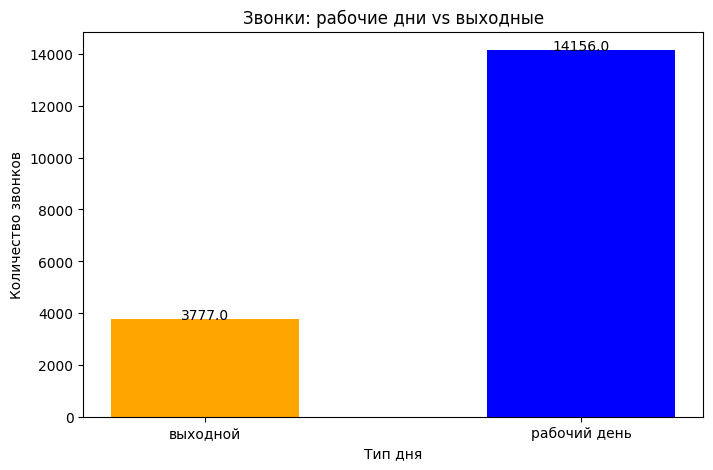

In [594]:
calls_by_weekday = df.groupby('weekday')['Y'].sum()
calls_by_weekday.index = ['выходной', 'рабочий день']
plt.figure(figsize=(8, 5))
plt.bar(calls_by_weekday.index, calls_by_weekday.values,
        color=['orange', 'blue'], width=0.5)

plt.title('Звонки: рабочие дни vs выходные')
plt.xlabel('Тип дня')
plt.ylabel('Количество звонков')

for i, value in enumerate(calls_by_weekday.values):
    plt.text(i, value + 0.5, str(value), ha='center')

plt.show()

In [595]:
df.head()

,Date,Y,TV,OOH,Seasonal_Sales,Usd_rate,TV_active,OOH_active,dayofweek,weekday
1,2013-01-02,0.0,0,0.0,0.060802,30.3372,False,False,2,1
2,2013-01-03,17.0,0,0.0,0.060802,30.1565,False,False,3,1
3,2013-01-04,17.0,0,0.0,0.060802,30.2710,False,False,4,1
4,2013-01-05,8.0,0,0.0,0.060802,30.2710,False,False,5,0
5,2013-01-06,14.0,0,0.0,0.060802,30.2710,False,False,6,0


### Корреляционный анализ

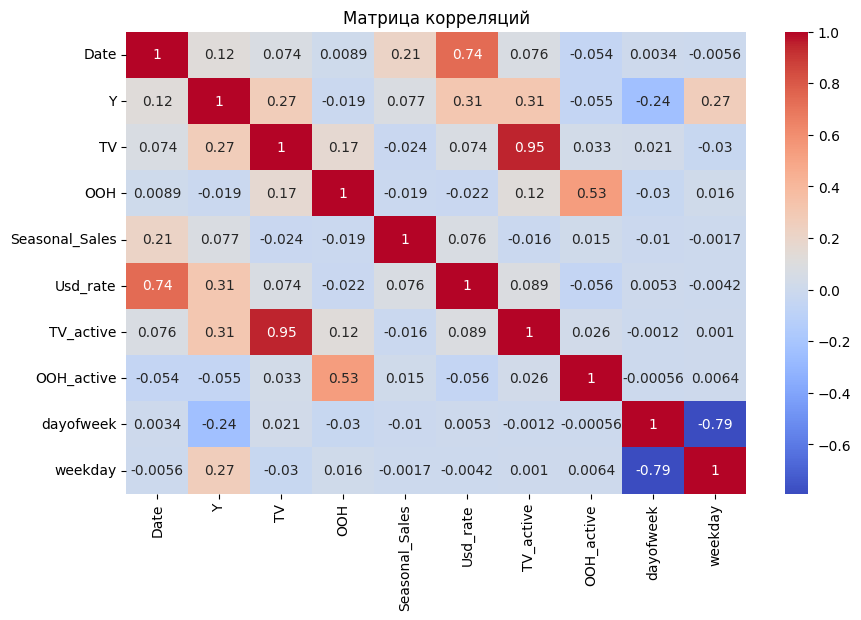

In [596]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Из признаков dayofweek и weekday заметим, что dayofweek создало слабуюотрицательную корреляцию с цеелвой переменной, в отличие от weekday

In [597]:
df.drop(columns=['dayofweek'], inplace=True)

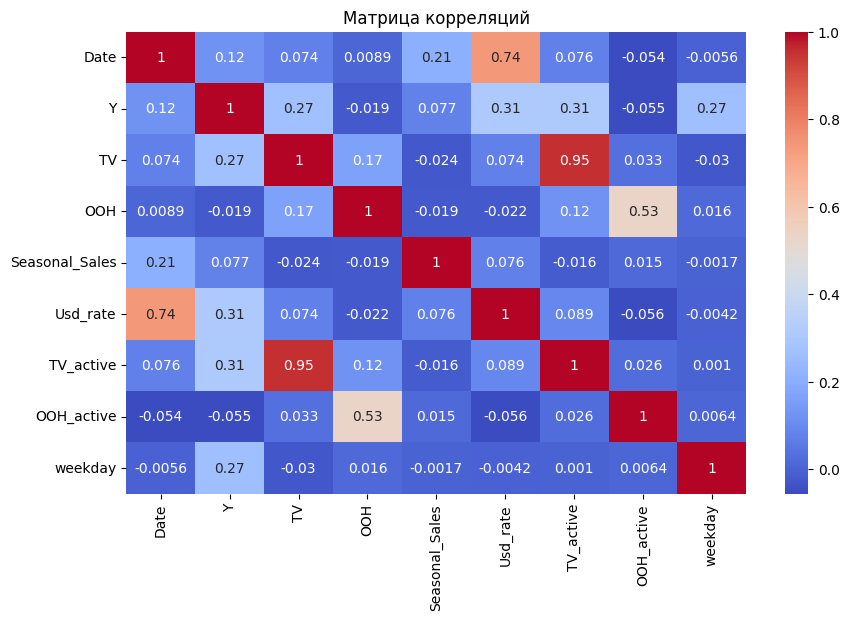

In [598]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Видно, что добавление новых признаков (TV_active = 0.31, OOH_active = -0.55) несильно помогло в анализе влияния на целевую переменную

In [599]:
df.head()

,Date,Y,TV,OOH,Seasonal_Sales,Usd_rate,TV_active,OOH_active,weekday
1,2013-01-02,0.0,0,0.0,0.060802,30.3372,False,False,1
2,2013-01-03,17.0,0,0.0,0.060802,30.1565,False,False,1
3,2013-01-04,17.0,0,0.0,0.060802,30.2710,False,False,1
4,2013-01-05,8.0,0,0.0,0.060802,30.2710,False,False,0
5,2013-01-06,14.0,0,0.0,0.060802,30.2710,False,False,0


Анализурая данную матрицу, можно сказать, что сила связи между признаками:
- Y(Usd_rate) = 0.31 - умеренная


В остальных случаях связь либо слабая/вовсе нет

Проанализируем связь остальных признаков - Usd_rate, Seasonal_sales с целевой переменной Y

### График звонков от курса доллара

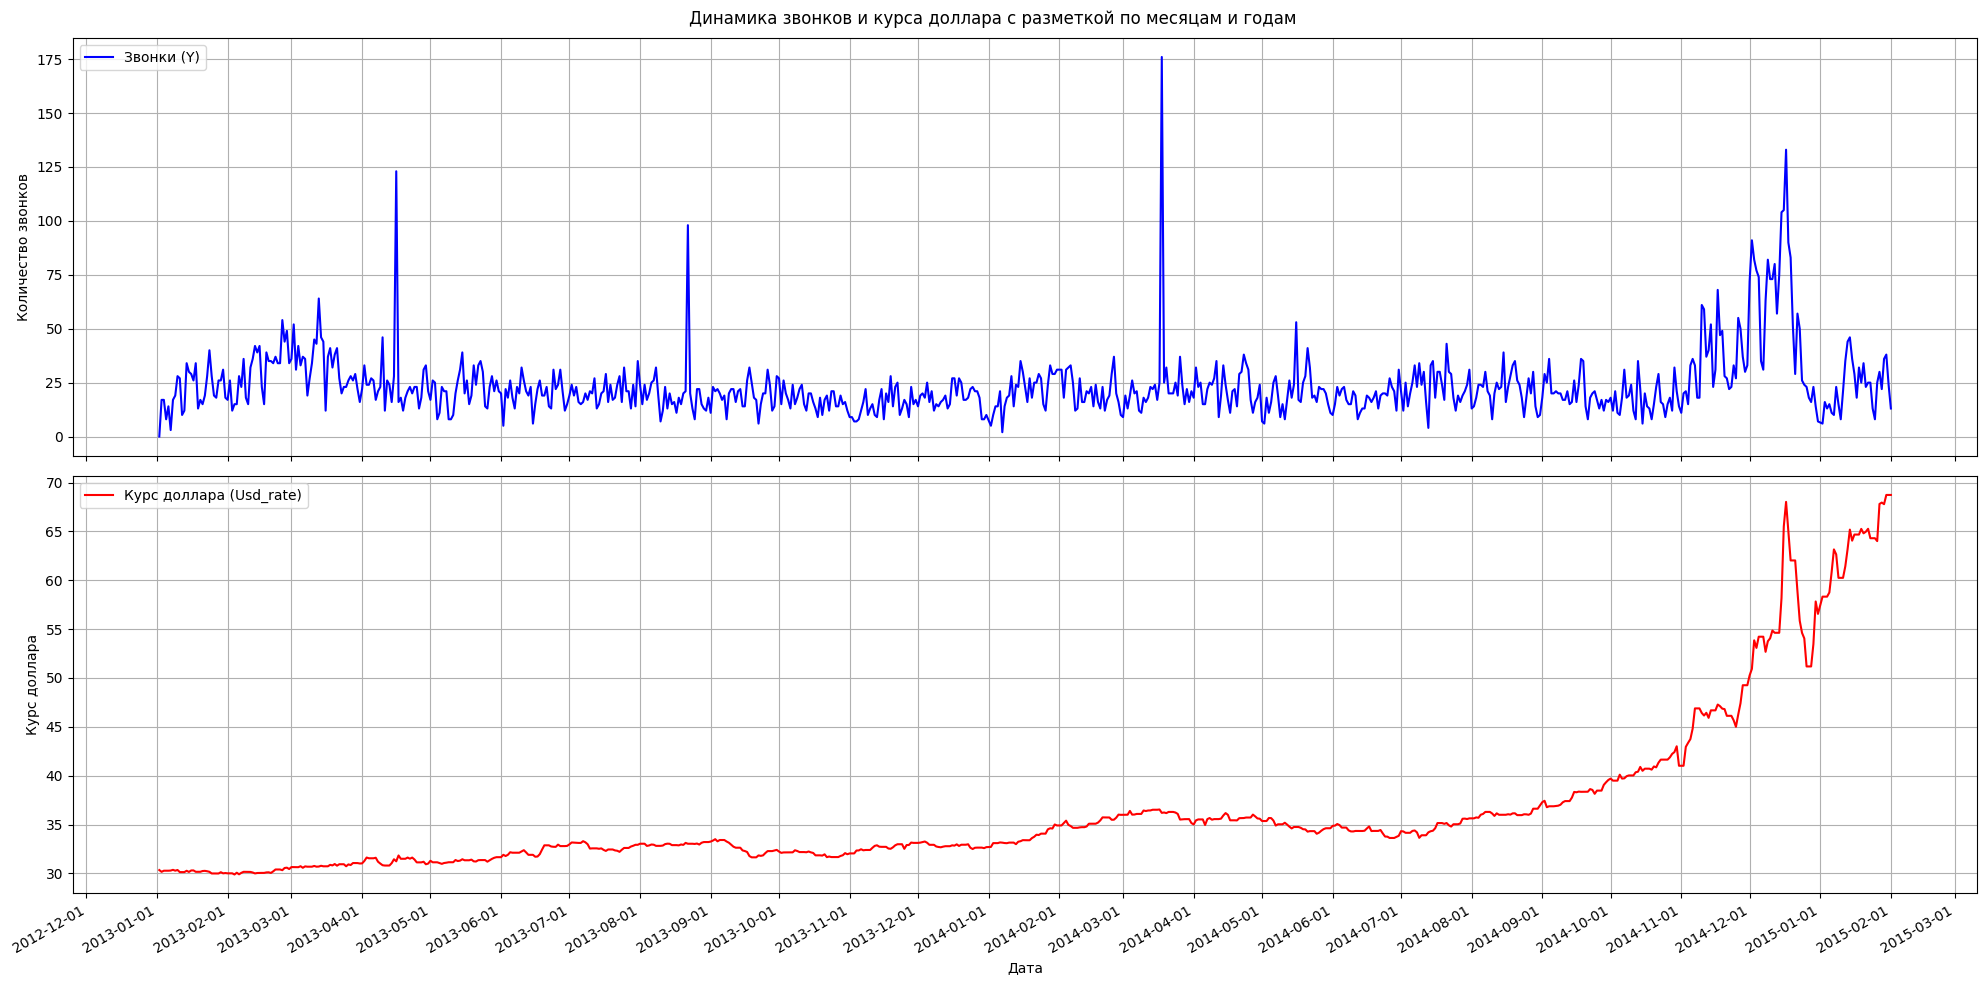

In [600]:
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(20, 10), sharex=True)

ax1.plot(df['Date'], df['Y'], color='blue', label='Звонки (Y)')
ax1.set_ylabel('Количество звонков')
ax1.grid(True)
ax1.legend(loc='upper left')

ax2.plot(df['Date'], df['Usd_rate'], color='red', label='Курс доллара (Usd_rate)')
ax2.set_xlabel('Дата')
ax2.set_ylabel('Курс доллара')
ax2.grid(True)
ax2.legend(loc='upper left')

ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax2.xaxis.set_minor_locator(mdates.YearLocator())
ax2.grid(which='minor', alpha=0.3)

fig.autofmt_xdate()

plt.suptitle('Динамика звонков и курса доллара с разметкой по месяцам и годам')
plt.tight_layout()
plt.show()

При увеличении курса к концу 2014 года заметно, что увеличилось число звонков.
Также, если обратить внимание на момент ~апреля 2014 года, то можно заметить, что также незначительно увеличелось Usd_rate, но это очень хорошо отразилось на количестве звонков.

Скорее важно не само значение курса, а его скорость изменения

#### Добавим изменения курса:
- дневное (процентное и абсолютное)
- скользящее среднее за 3 дня
- недельное (процентное и скользящее среднее)

In [601]:
# Рассчитаем дневные процентные изменения курса
df['usd_daily_change'] = df['Usd_rate'].pct_change() * 100
# Альтернативно: абсолютное изменение курса
df['usd_absolute_change'] = df['Usd_rate'].diff()

# Сгладим градиент скользящим средним за 3 дня (чтобы уменьшить шум)
df['usd_change_smooth'] = df['usd_daily_change'].rolling(3).mean()

# Изменение за 7 дней относительно текущего дня
for lag in [7, 14, 21, 28]:
  df[f'usd_weekly_{lag}_gradient'] = (df['Usd_rate'] / df['Usd_rate'].shift(lag) - 1) * 100

# Скользящее среднее ежедневных изменений за неделю
for lag in range(1, 21):
  df[f'usd_weekly_smooth_{lag}_gradient'] = df['usd_daily_change'].rolling(lag).mean()

"""df['usd_trend'] = pd.cut(df['usd_daily_change'],
                         bins=[-np.inf, -1, 1, np.inf],
                         labels=['падение', 'стабильно', 'рост'])
"""

"df['usd_trend'] = pd.cut(df['usd_daily_change'], \n                         bins=[-np.inf, -1, 1, np.inf], \n                         labels=['падение', 'стабильно', 'рост'])\n"

Имеет смысл построить матрицу корреляции, чтобы посмотреть связь целевой переменной с нвоыми признаками

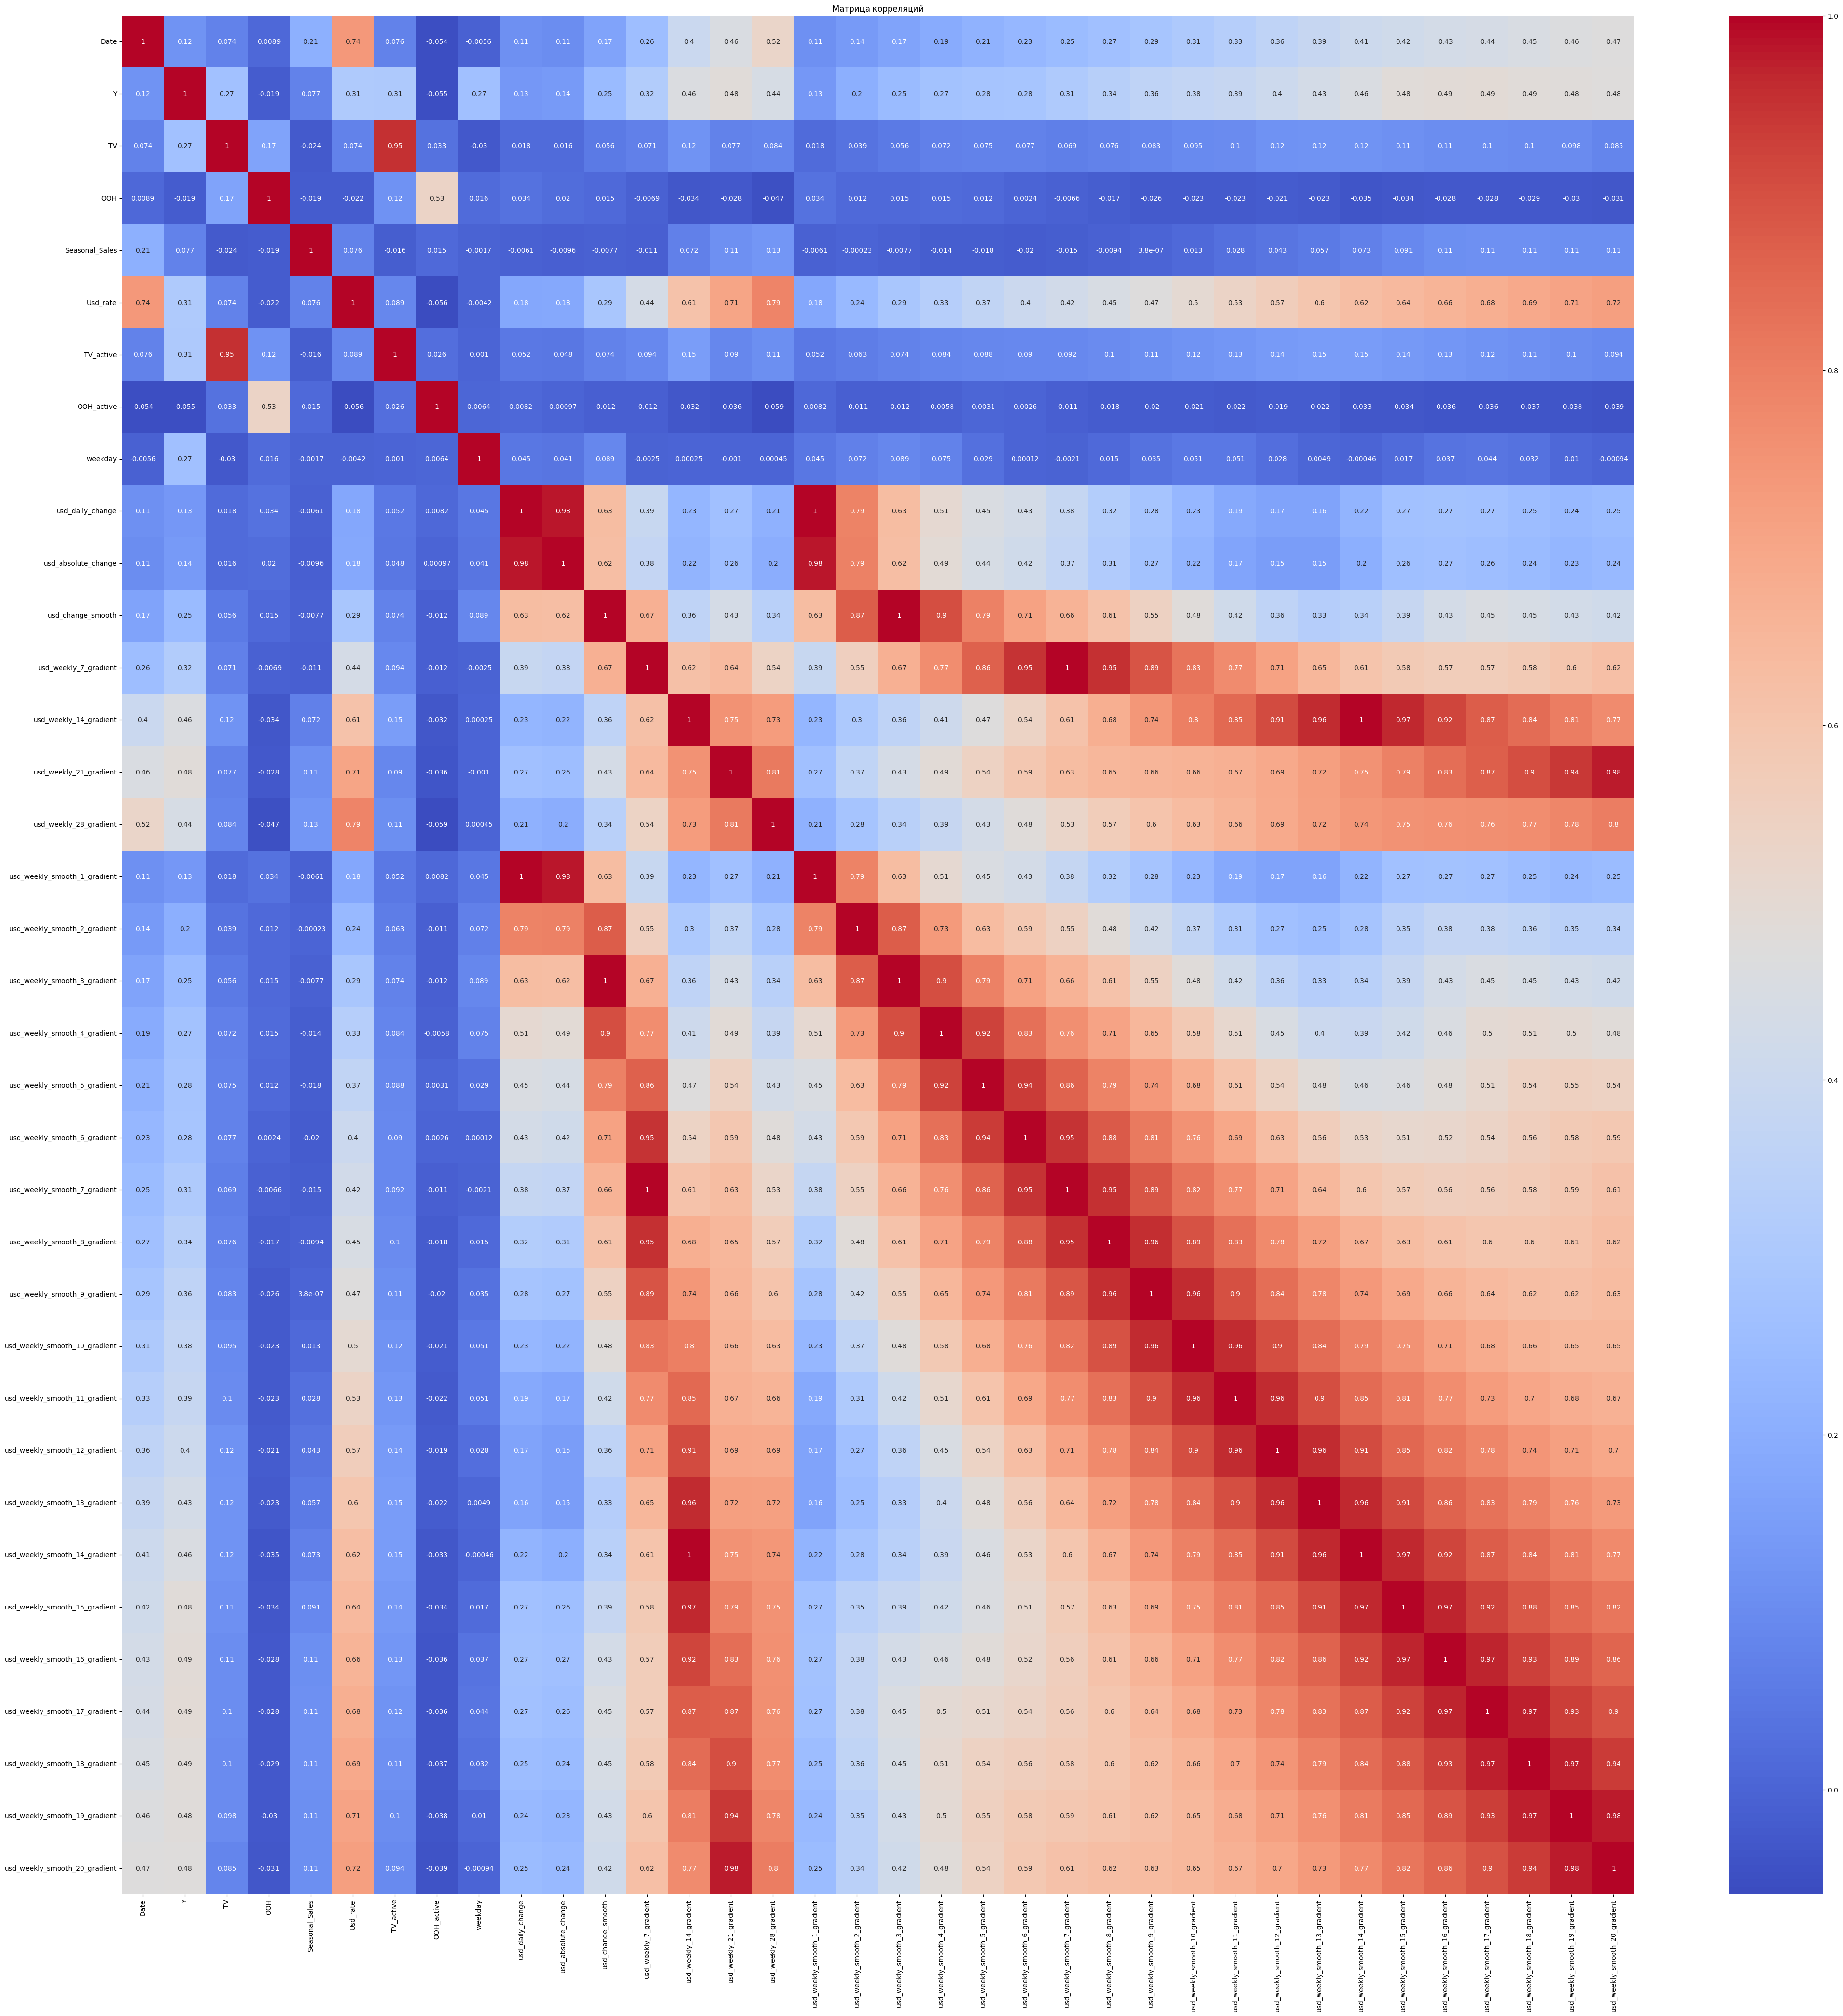

In [602]:
plt.figure(figsize=(50, 50))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

Заметим, что появилась умеренная корреляция между признаком usd_weekly_lag_gradient с целевой перемнной = 0.48 (lag = 21, 22) и при увеличении временной сдвижки с 21 до 28 коэффициент корреляции упал до 0.44. Также usd_weekly_smooth_lag_gradient = 0.49 (lag = 16, 17, 18), и при увеличении временной сдвижки с 17 до 21 коэффициент корреляции упал до 0.48.

Поэтому имеет смысл оставить usd_weekly_smooth_17_gradient, а остальные признаки удалить

In [603]:
columns_to_drop = [
    *[f'usd_weekly_{i}_gradient' for i in [7, 14, *range(21, 29)]],
    *[f'usd_weekly_smooth_{i}_gradient' for i in [*range(1, 17), *range(18, 22)]],
    'usd_daily_change',
    'usd_absolute_change',
    'usd_change_smooth',
    'usd_weekly_smooth_gradient'
]

df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

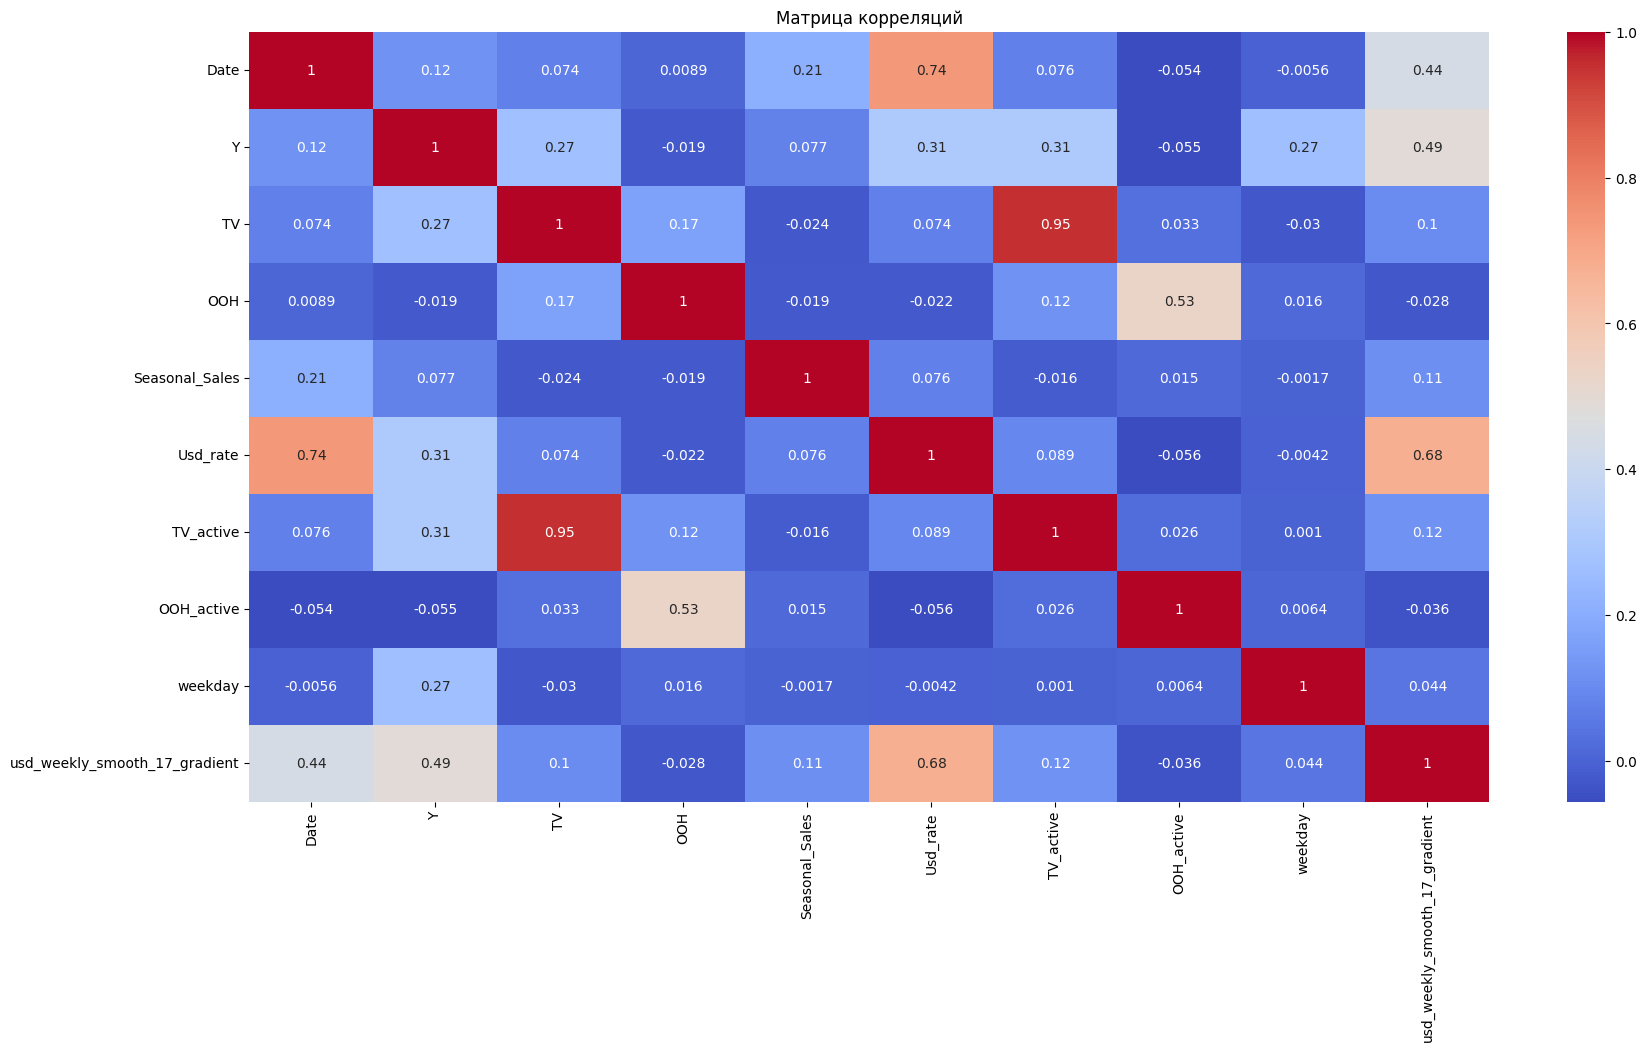

In [604]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

### Связь остальных признаков

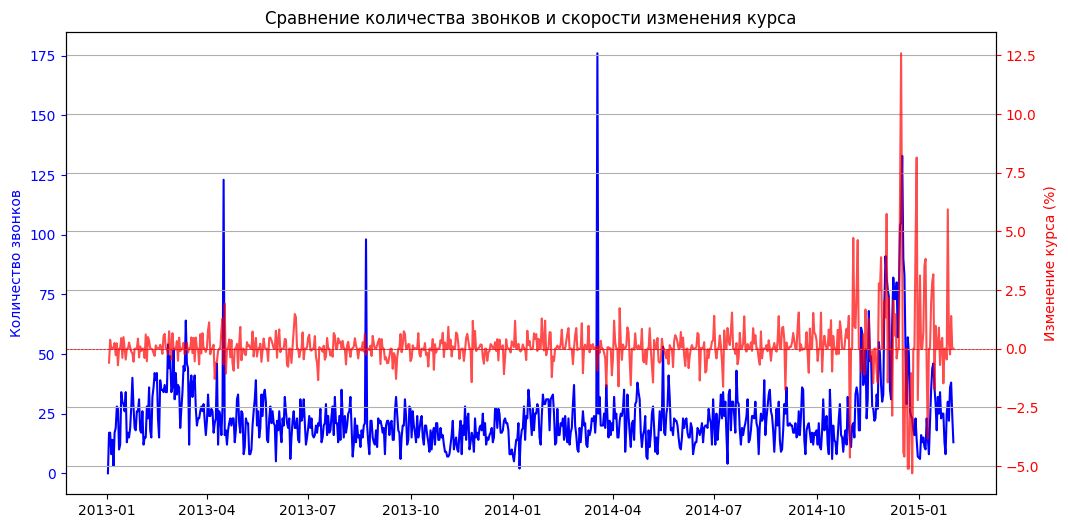

In [309]:
plt.figure(figsize=(12, 6))

ax1 = plt.gca()
ax1.plot(df['Date'], df['Y'], color='blue', label='Звонки')
ax1.set_ylabel('Количество звонков', color='blue')
ax1.tick_params(axis='y', colors='blue')

ax2 = ax1.twinx()
ax2.plot(df['Date'], df['usd_daily_change'], color='red', alpha=0.7, label='Изменение курса (%)')
ax2.set_ylabel('Изменение курса (%)', color='red')
ax2.tick_params(axis='y', colors='red')
ax2.axhline(0, color='red', linestyle='--', linewidth=0.5)

plt.title('Сравнение количества звонков и скорости изменения курса')
plt.grid(True)
plt.show()

In [271]:
# Группируем по месяцу и году, нормируем Y
df['Y_monthly_norm'] = df.groupby([df['Date'].dt.year, df['Date'].dt.month])['Y'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() if (x.max() - x.min()) != 0 else 1)
)

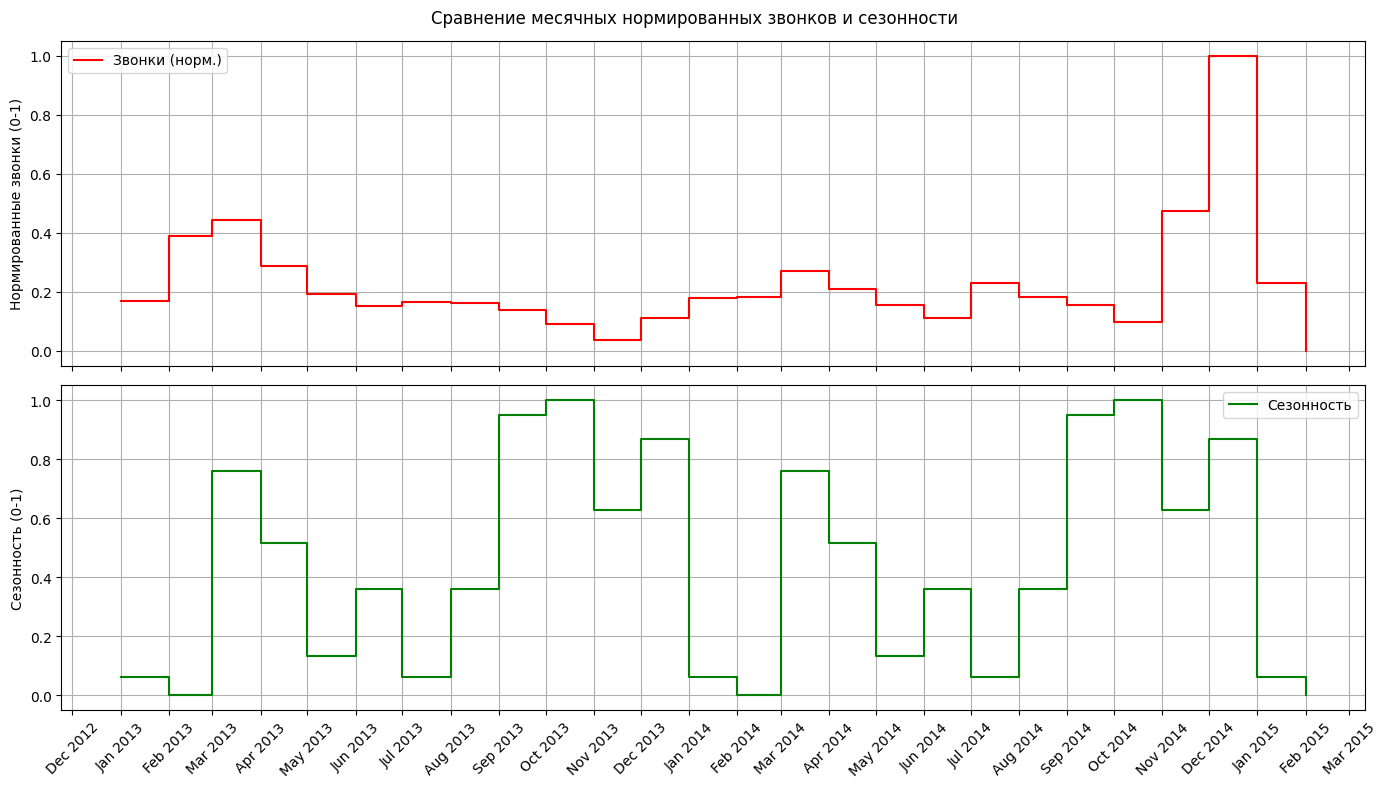

In [247]:
import matplotlib.dates as mdates

# 1. Создаем колонку с первым числом каждого месяца (для группировки)
df['Month_Start'] = df['Date'].dt.to_period('M').dt.to_timestamp()

# 2. Агрегируем Y по месяцам (например, среднее значение)
monthly_data = df.groupby('Month_Start').agg({
    'Seasonal_Sales': 'first',  # берем первое значение (они одинаковы в месяце)
    'Y': 'mean'                 # среднее количество звонков в месяце
}).reset_index()

# 3. Нормируем Y в шкалу 0-1 (по всему датасету)
monthly_data['Y_norm'] = (monthly_data['Y'] - monthly_data['Y'].min()) / \
                         (monthly_data['Y'].max() - monthly_data['Y'].min())

# 4. Строим ступенчатые графики
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

# График нормированных звонков
ax1.step(monthly_data['Month_Start'], monthly_data['Y_norm'],
         where='post', color='red', label='Звонки (норм.)')
ax1.set_ylabel('Нормированные звонки (0-1)')
ax1.legend()
ax1.grid(True)

# График сезонности
ax2.step(monthly_data['Month_Start'], monthly_data['Seasonal_Sales'],
         where='post', color='green', label='Сезонность')
ax2.set_ylabel('Сезонность (0-1)')
ax2.legend()
ax2.grid(True)

# Форматирование дат
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.suptitle('Сравнение месячных нормированных звонков и сезонности')
plt.tight_layout()
plt.show()

In [193]:
df.head()

,Date,Y,TV,OOH,Seasonal_Sales,Usd_rate,TV_active,OOH_active,weekday,Y_monthly_norm
1,2013-01-02,0.0,0,0.0,0.060802,30.3372,False,False,1,0.000
2,2013-01-03,17.0,0,0.0,0.060802,30.1565,False,False,1,0.425
3,2013-01-04,17.0,0,0.0,0.060802,30.2710,False,False,1,0.425
4,2013-01-05,8.0,0,0.0,0.060802,30.2710,False,False,0,0.200
5,2013-01-06,14.0,0,0.0,0.060802,30.2710,False,False,0,0.350


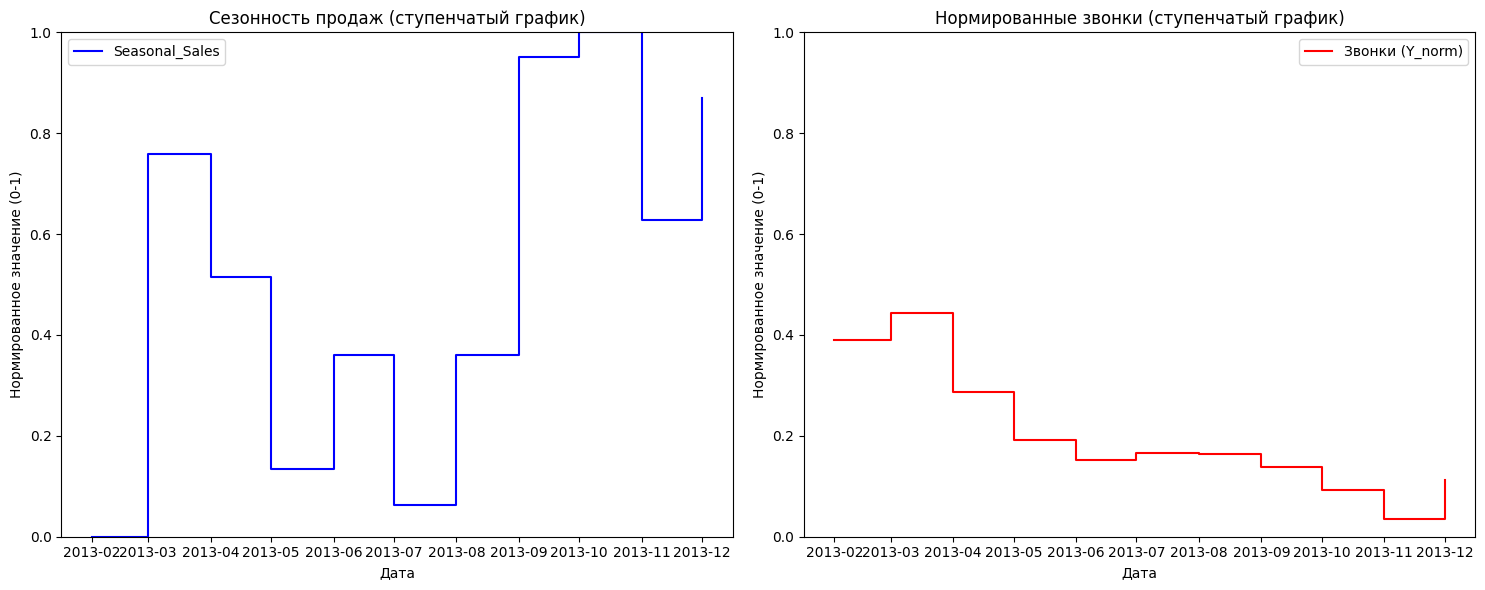

# основные замечания:
- поделить значения на до октября 14 и после - т.е. уидить градиент сильного изменения

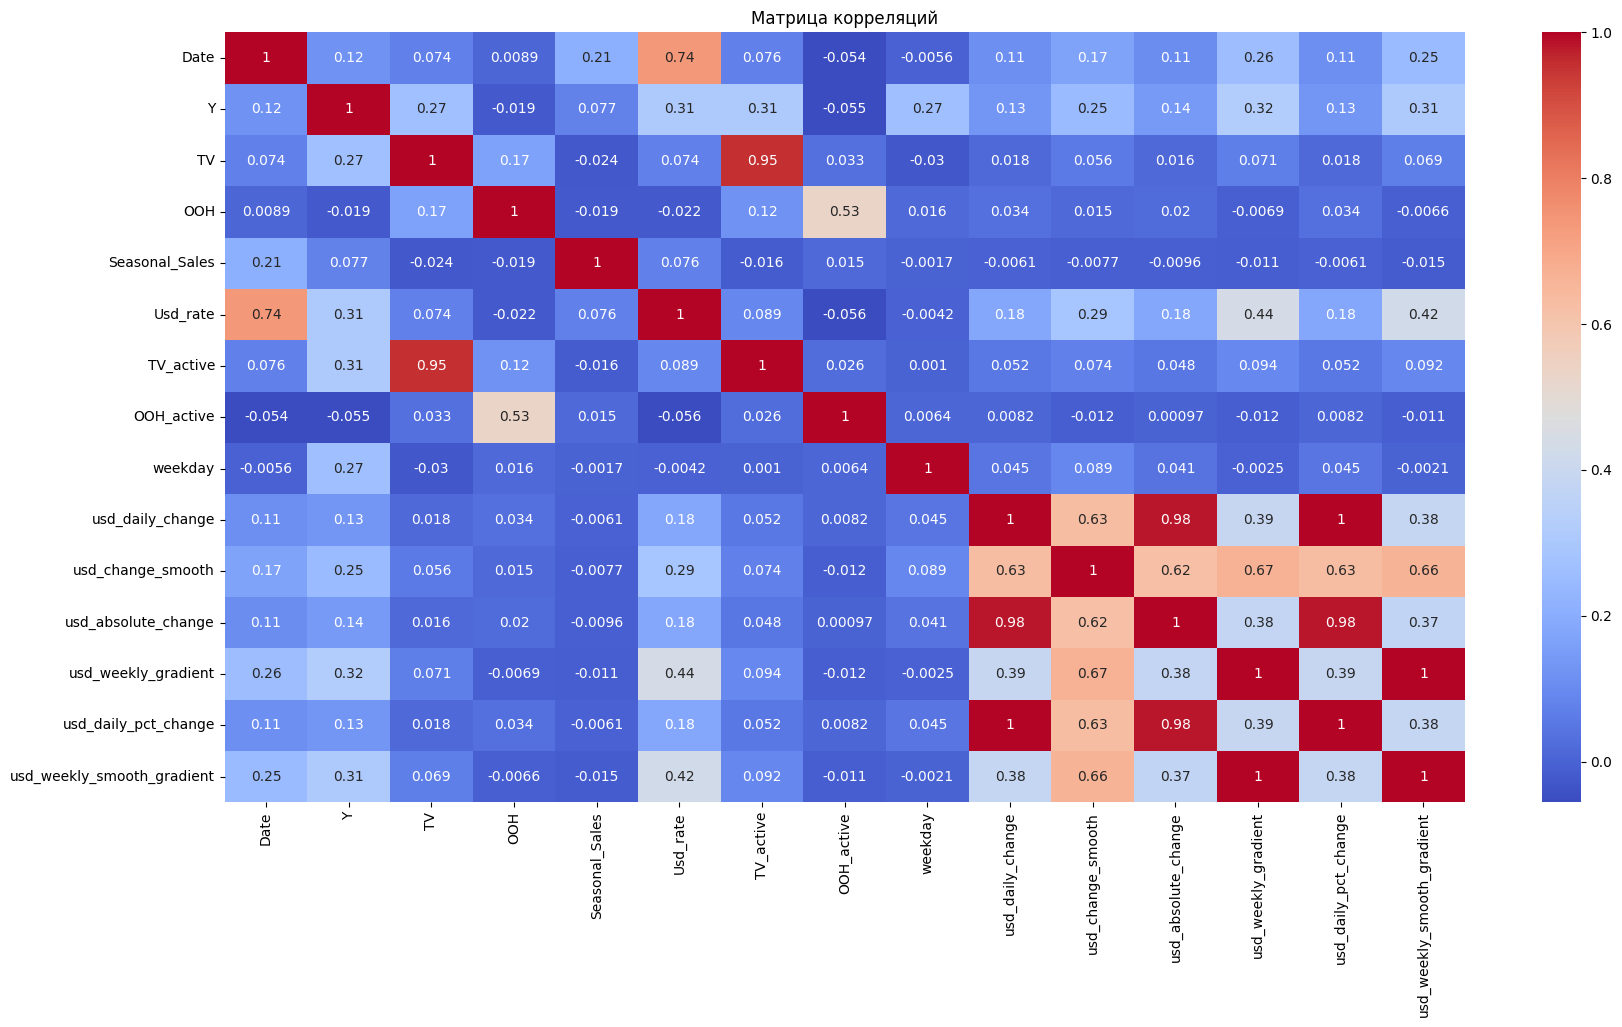

In [145]:
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

### Анализ по месяцам/годам
группировка по месяцам:

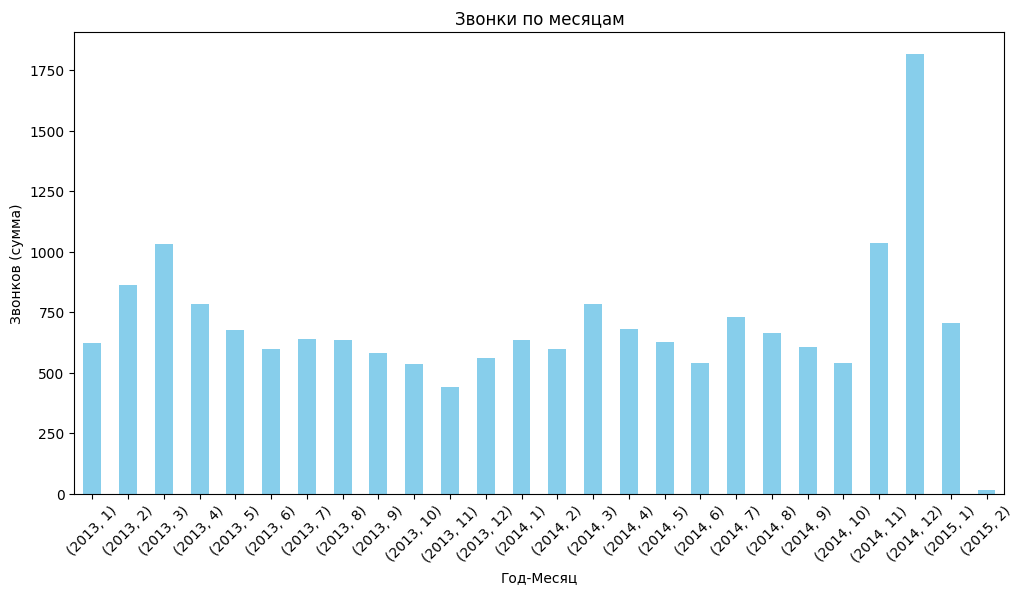

In [146]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
monthly_data = df.groupby(['Year', 'Month']).agg({'Y': 'sum', 'TV': 'sum', 'OOH': 'sum'})

plt.figure(figsize=(12, 6))
monthly_data['Y'].plot(kind='bar', color='skyblue')
plt.title('Звонки по месяцам')
plt.xlabel('Год-Месяц')
plt.ylabel('Звонков (сумма)')
plt.xticks(rotation=45)
plt.show()

Заметим, что больше всего звонков было сделано на момент 12.2024. из прошлого графика мы знаем, что это связано с увеличением курса

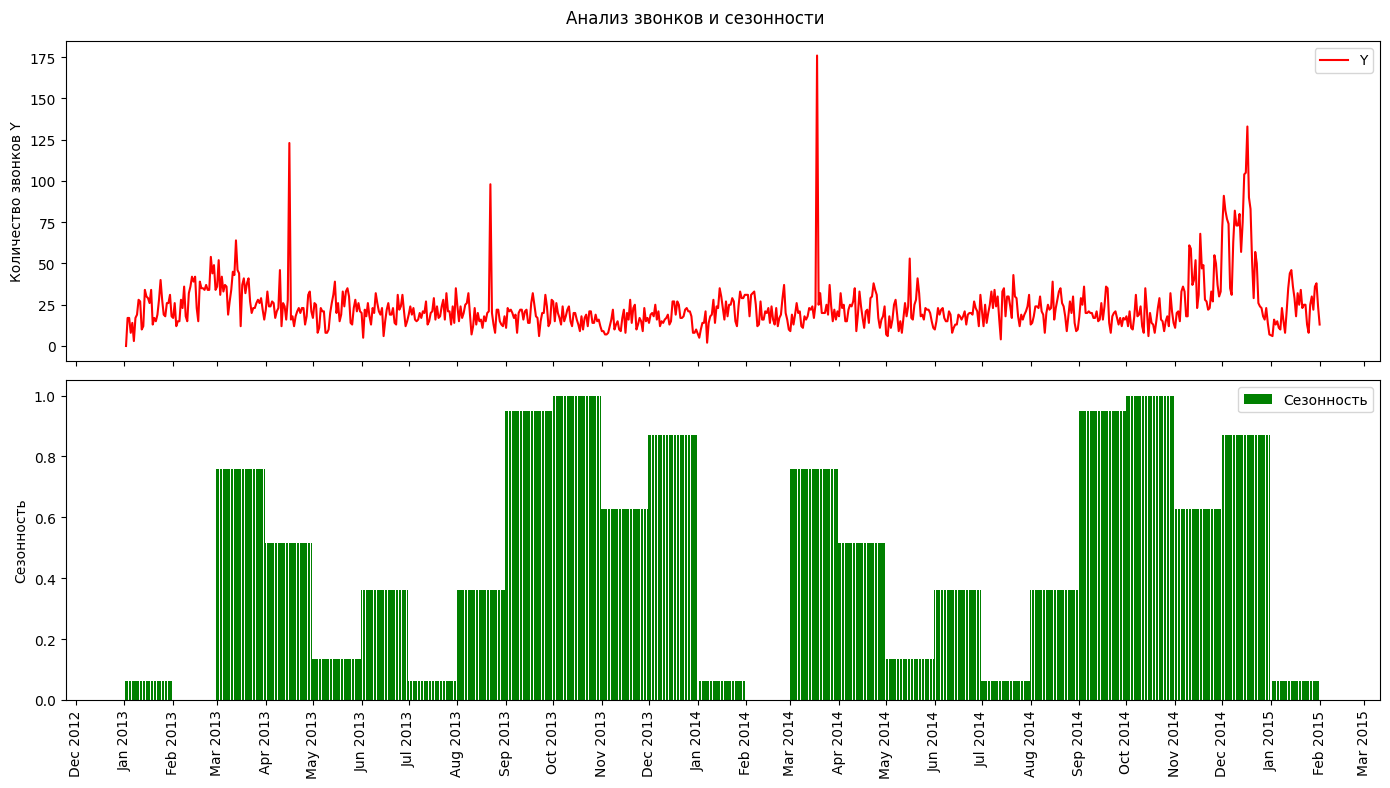

In [147]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True)

ax1.plot(df['Date'], df['Y'], color='red', label='Y')

ax1.set_ylabel('Количество звонков Y')
ax1.legend()

ax2.bar(df['Date'], df['Seasonal_Sales'], color='green', label='Сезонность')
ax2.set_ylabel('Сезонность')
ax2.legend()
import matplotlib.dates as mdates
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)


plt.suptitle('Анализ звонков и сезонности')
plt.tight_layout()
plt.show()

Тут можем заметить некую особенность "Сезонности": здесь наблюдается, что в период с января по март никакой активности нет, а пики в свою очередь приурочены к датам: апрель 2013, август 2013, март 2014, декабрь 2014

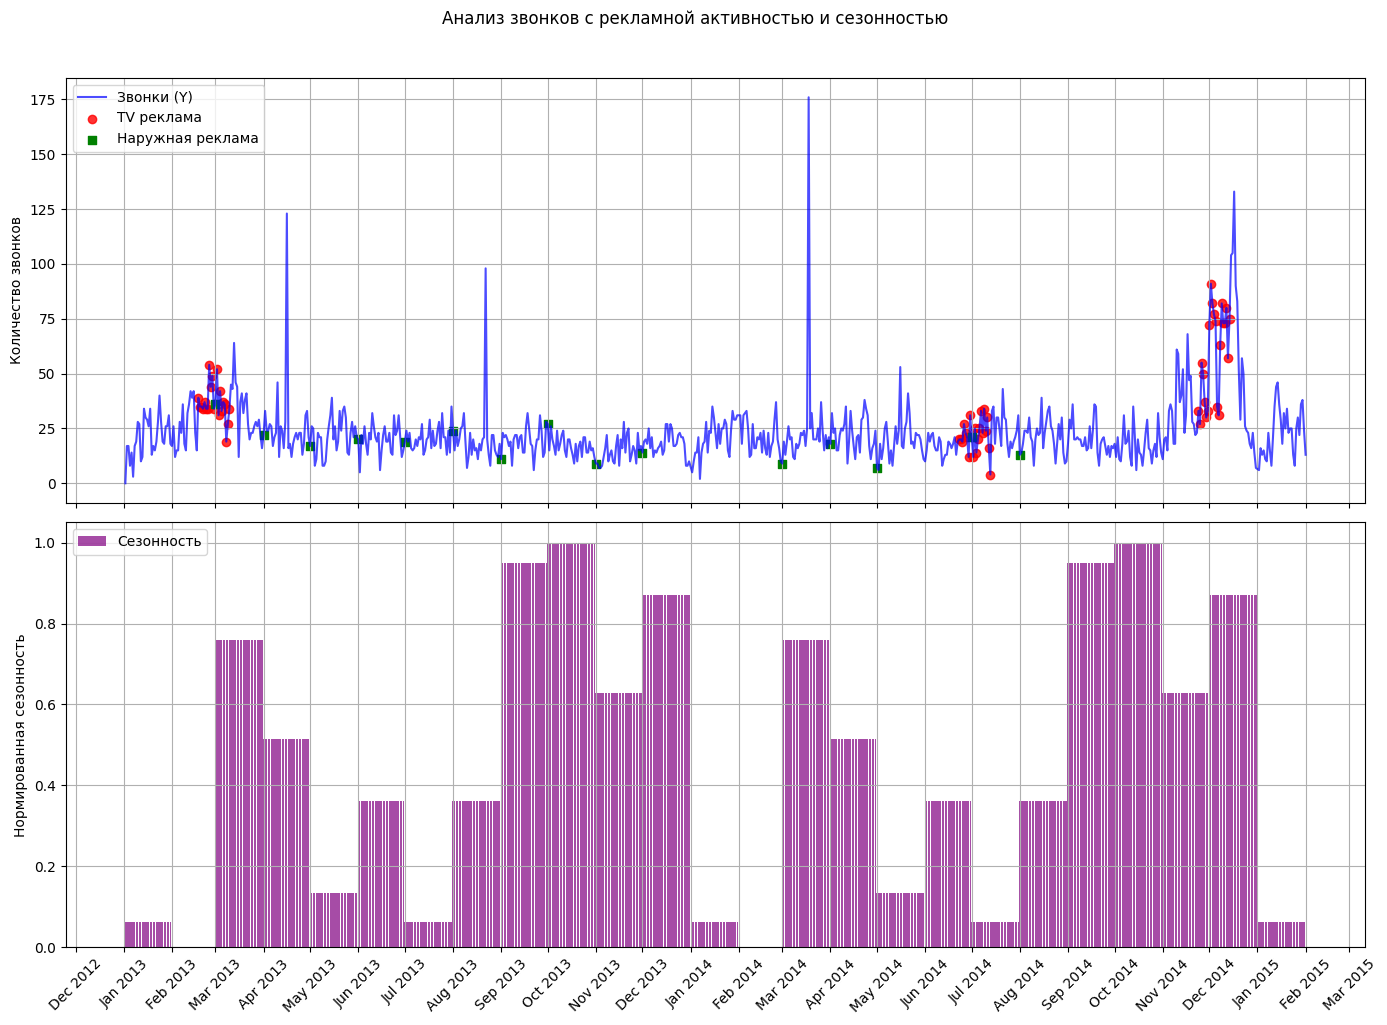

In [148]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

ax1.plot(df['Date'], df['Y'], color='blue', label='Звонки (Y)', alpha=0.7)

tv_active = df[df['TV'] > 0]
ax1.scatter(tv_active['Date'], tv_active['Y'],
           color='red', marker='o',
           label='TV реклама', alpha=0.8)

ooh_active = df[df['OOH'] > 0]
ax1.scatter(ooh_active['Date'], ooh_active['Y'],
           color='green', marker='s',
           label='Наружная реклама', alpha=1)

ax1.set_ylabel('Количество звонков')
ax1.legend(loc='upper left')
ax1.grid(True)

ax2.bar(df['Date'], df['Seasonal_Sales'],
       color='purple', label='Сезонность', alpha=0.7)
ax2.set_ylabel('Нормированная сезонность')
ax2.legend(loc='upper left')
ax2.grid(True)

ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.suptitle('Анализ звонков с рекламной активностью и сезонностью', y=1.02)
plt.tight_layout()
plt.show()

#### Для анализа временной ряда неплохо было бы сделать лаги целевой переменной и рекламных факторов

In [149]:
"""for lag in [1, 3, 7]:
    df[f'Y_lag_{lag}'] = df['Y'].shift(lag)

for lag in [7, 14]:
    df[f'Y_rolling_mean_{lag}'] = df['Y'].rolling(lag).mean()
    #df[f'Y_rolling_std_{window}'] = df['Y'].rolling(window).std()
    #df[f'Y_rolling_max_{window}'] = df['Y'].rolling(window).max()
"""
for lag in range(1, 30):
    df[f'TV_lag_{lag}'] = df['TV'].shift(lag)

for lag in range(1, 30):
    df[f'OOH_lag_{lag}'] = df['OOH'].shift(lag)

df['Seasonal_lag_30'] = df['Seasonal_Sales'].shift(30)

# Усиление рекламы в "горячий" сезон
#df['OOH_boosted'] = df['OOH'] * df['Seasonal_Sales']
#df['changes_Usd_rate'] = (df['Usd_rate']/df['Usd_rate'].shift(1)-1)*100
#df = df.fillna(0)
df = df.dropna()

Text(0.5, 1.0, 'Матрица корреляций')

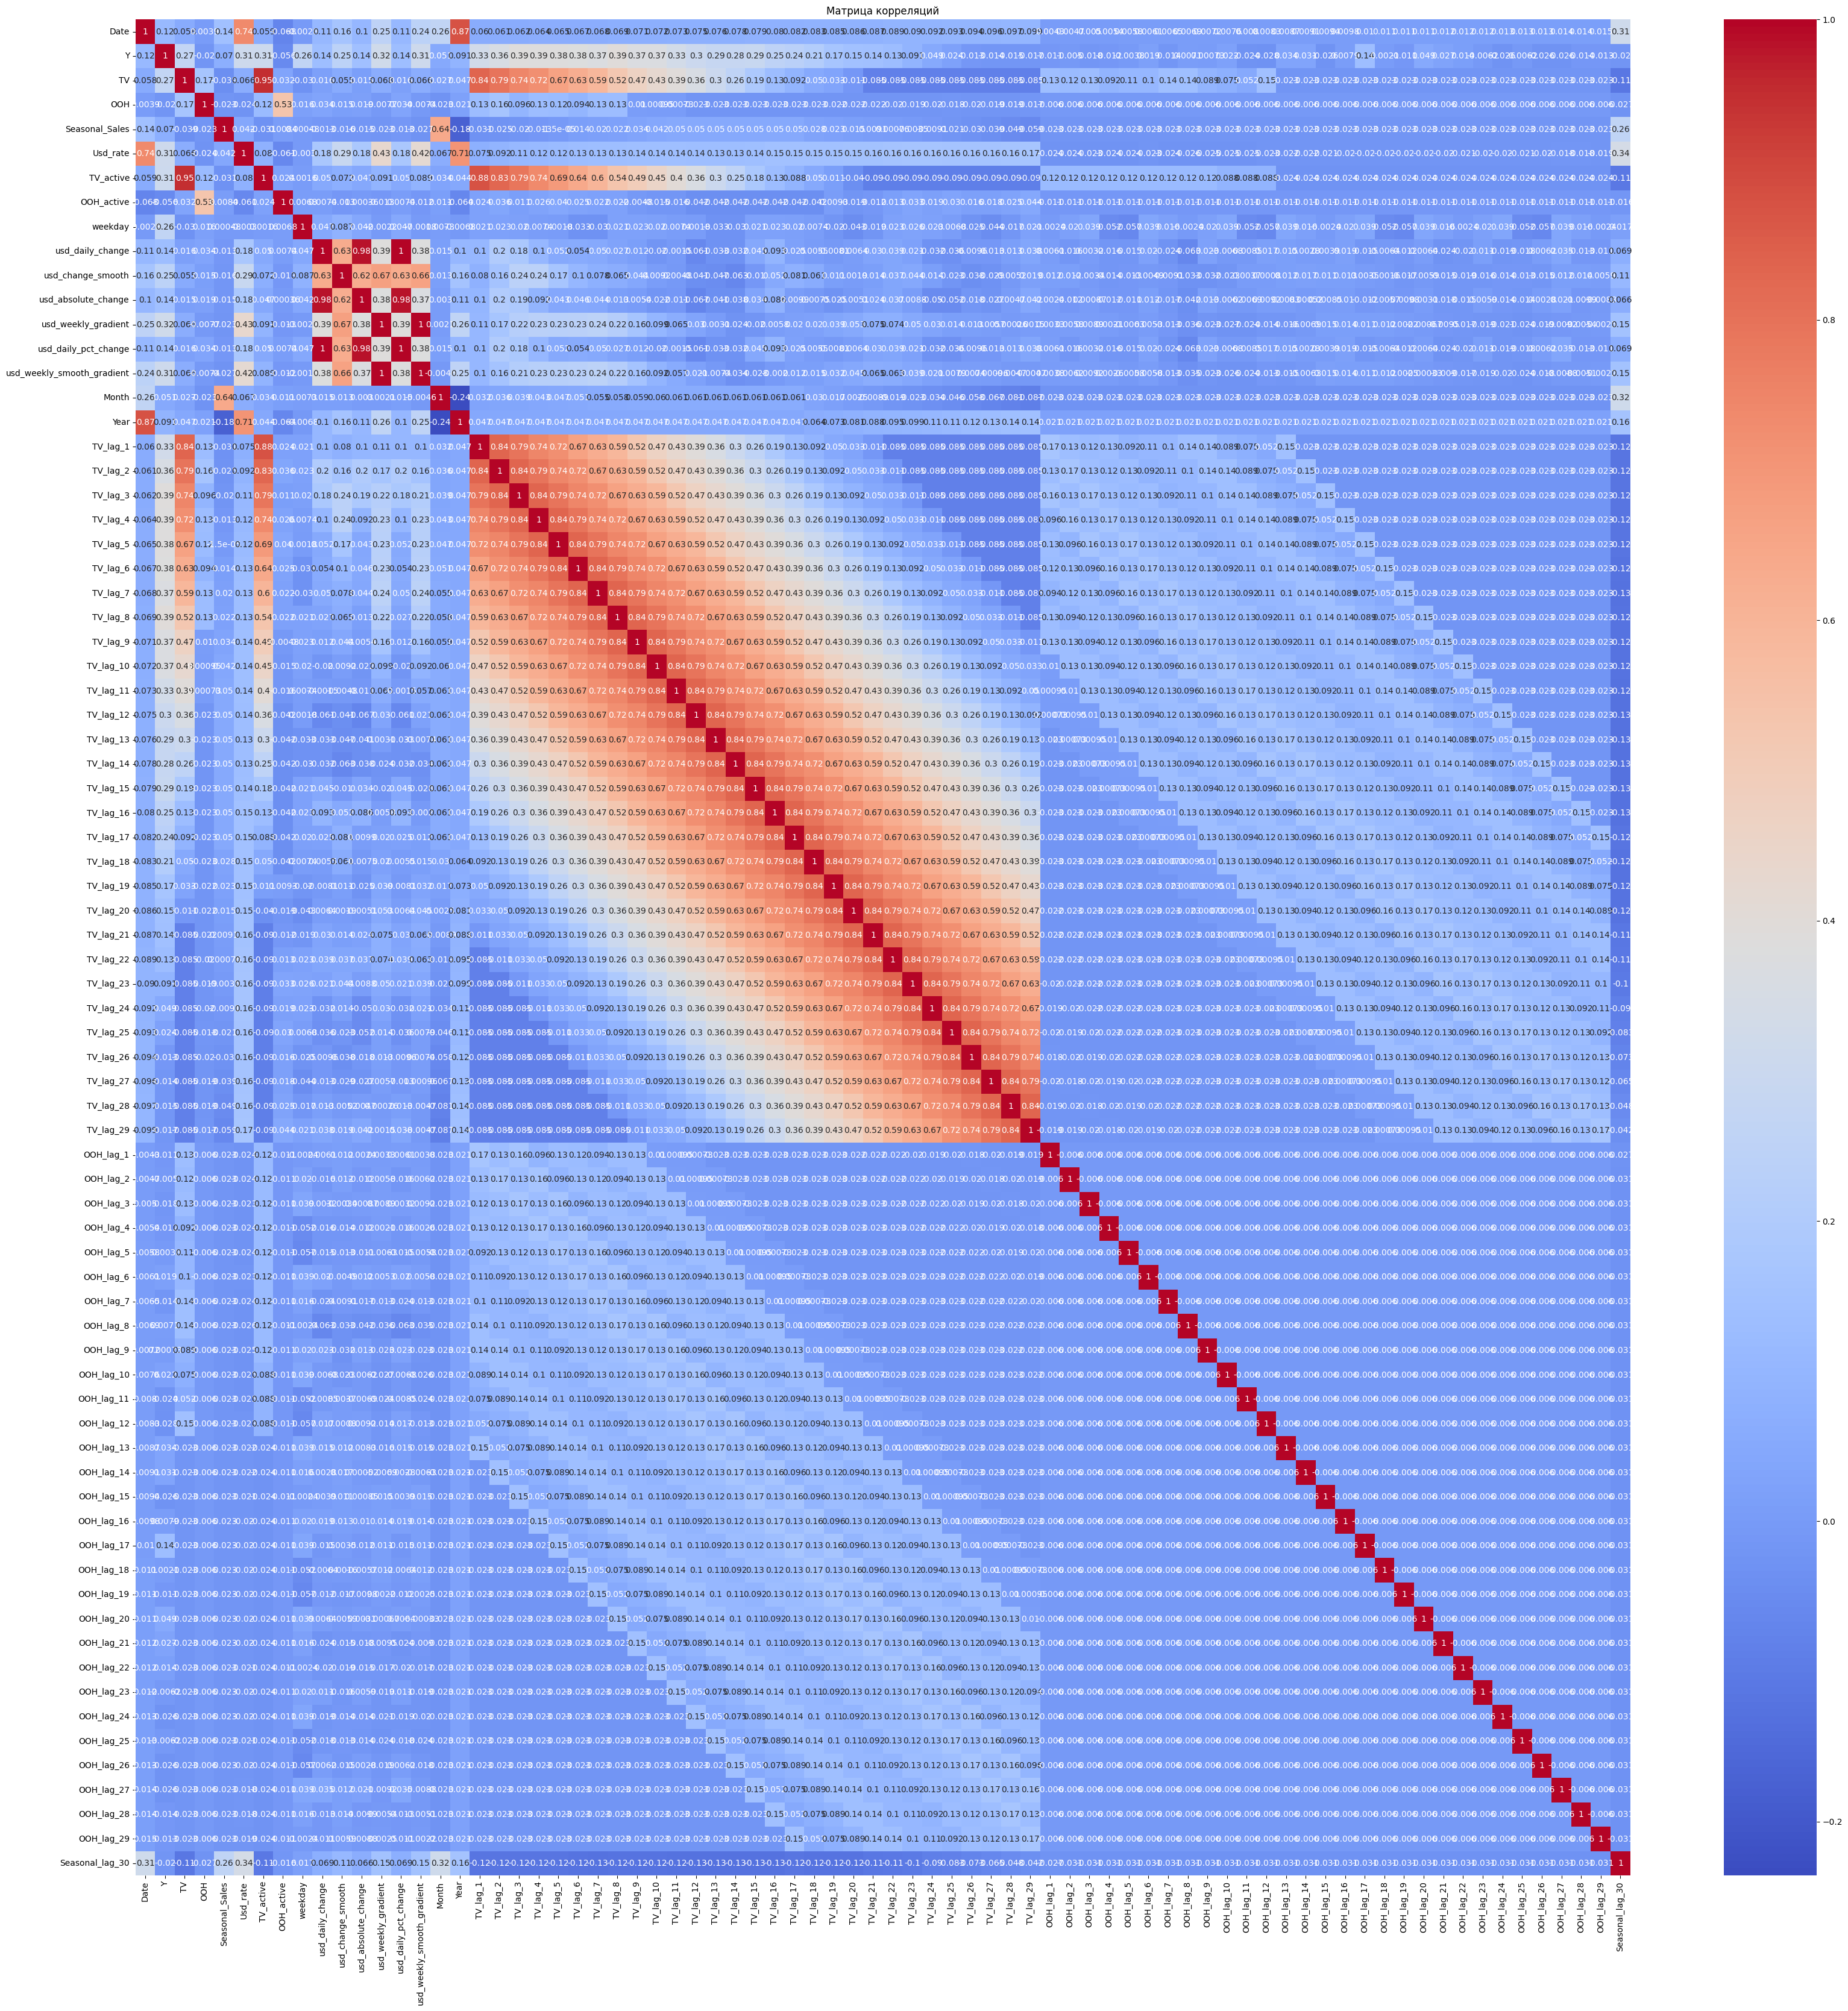

In [153]:
"""plt.figure(figsize=(40, 40))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
#plt.show()"""

In [159]:
corr_matrix = df.corr()
y_correlations = corr_matrix.loc['Y']  # Все корреляции с Y
y_correlations

,Y
Date,0.115392
Y,1.000000
TV,0.268385
OOH,-0.019945
Seasonal_Sales,0.070249
...,...
OOH_lag_26,-0.025713
OOH_lag_27,-0.025832
OOH_lag_28,-0.013733
OOH_lag_29,-0.012645


### б) построить регрессионную модель, выполнить её валидацию на отдельной подвыборке;

разобьем датасет на обучающую и тестовую выборки, но перед этим создадим признак day и удалим Date, т.к. fit не работает с признаком типа timestamp

In [ ]:
df['day'] = df['Date'].dt.day
df = df.set_index('Date')

In [ ]:
#df['TV_active'] = df['TV_active'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 714 entries, 2013-02-16 to 2015-02-01
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Y                           714 non-null    float64
 1   TV                          714 non-null    int64  
 2   OOH                         714 non-null    float64
 3   Seasonal_Sales              714 non-null    float64
 4   Usd_rate                    714 non-null    float64
 5   TV_active                   714 non-null    bool   
 6   OOH_active                  714 non-null    bool   
 7   dayofweek                   714 non-null    int32  
 8   usd_daily_change            714 non-null    float64
 9   usd_change_smooth           714 non-null    float64
 10  usd_absolute_change         714 non-null    float64
 11  usd_weekly_gradient         714 non-null    float64
 12  usd_daily_pct_change        714 non-null    float64
 13  usd_weekly_smoot

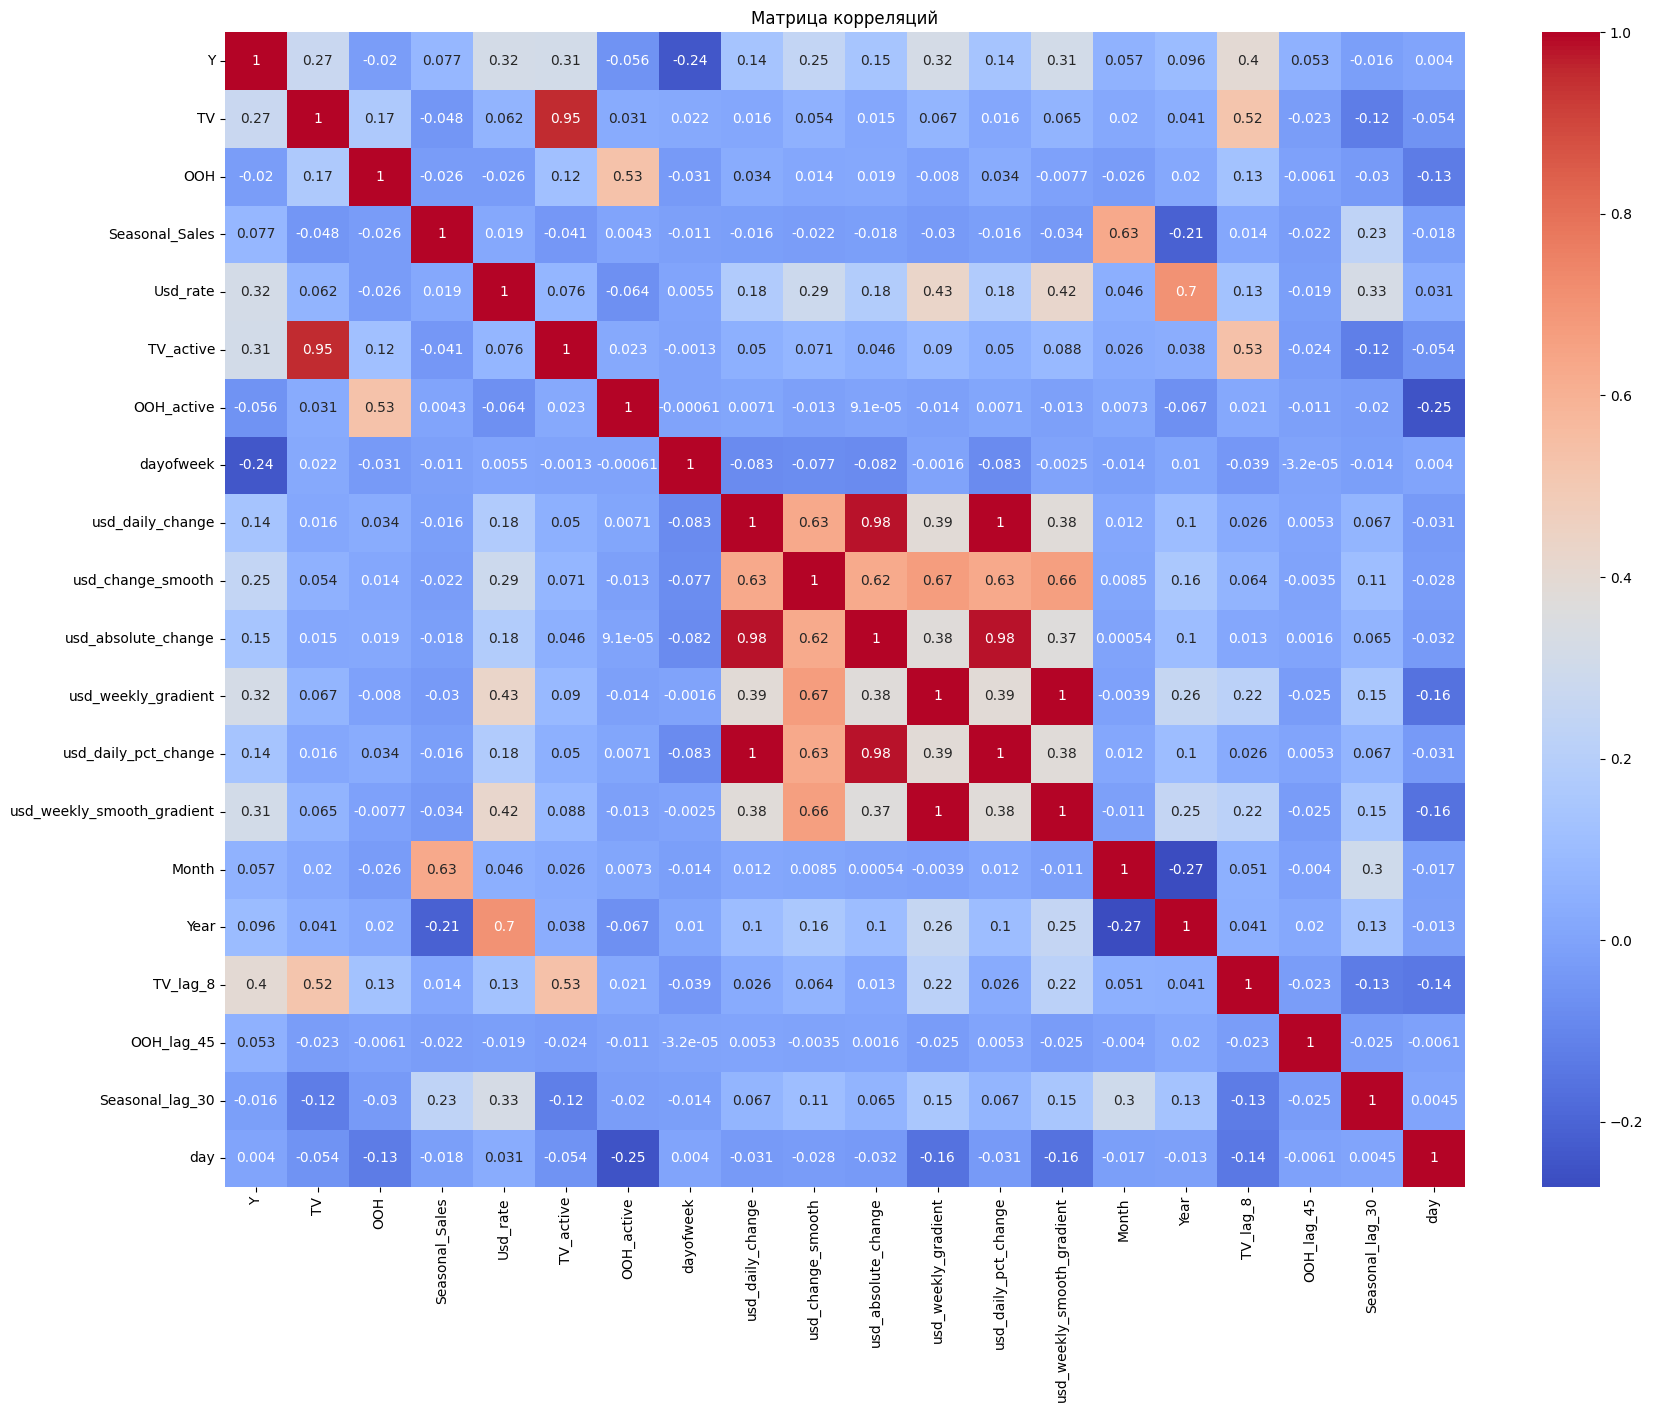

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [ ]:
df.drop(columns=['TV', 'TV_active', 'dayofweek', 'OOH', 'OOH_active', 'Seasonal_Sales', 'Usd_rate', 'usd_weekly_smooth_gradient', 'Month'], inplace=True)

KeyError: "['usd_weekly_pct_change'] not found in axis"

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [ ]:
df.head(3)

In [ ]:
df.isna().sum()

In [ ]:
#df['OOH_active'] = df['OOH_active'].astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler


#### Для обучения буду использовать 80% данных и не прибегать к train_test_split т.к. он может разрушить временные зависимости

In [ ]:
train_size = int(len(df) * 0.8)  # 80% данных — тренировка
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(columns=['Y'])
y_train = train['Y']
X_test = test.drop(columns=['Y'])
y_test = test['Y']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit только на train!
X_test_scaled = scaler.transform(X_test)        # transform на test

In [ ]:
#from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

model = LinearRegression()
#model = RandomForestRegressor()

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
"""from sklearn.ensemble import GradientBoostingRegressor

params = {
    'n_estimators': 200,
    'max_depth': 3,
    'learning_rate': 0.05
}

model = GradientBoostingRegressor(**params).fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)"""

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_squared_error(y_test, y_pred))

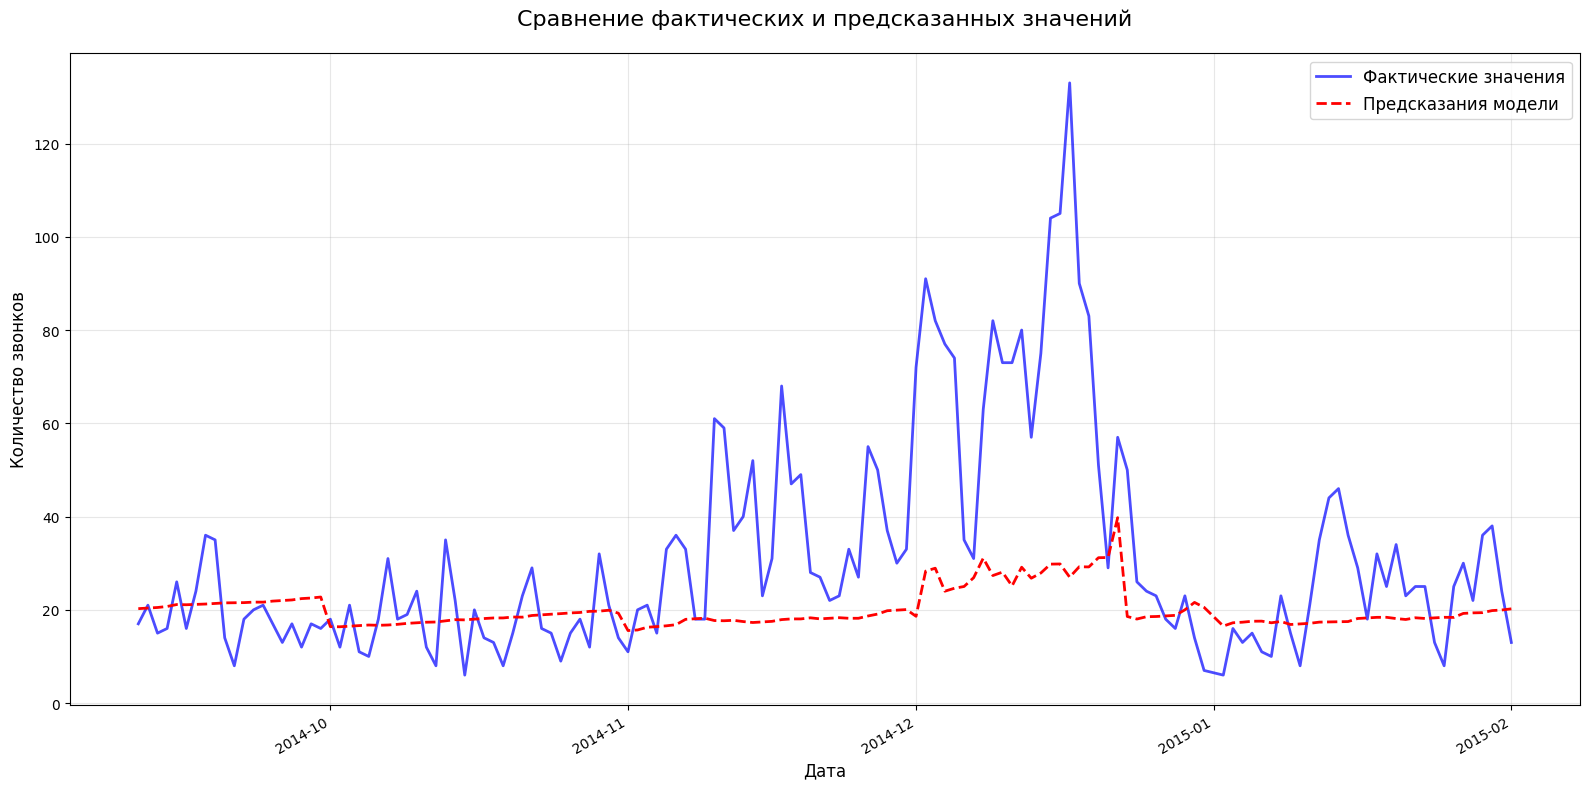

In [ ]:
# После получения предсказаний (y_test и y_pred)
plt.figure(figsize=(16, 8))

# Фактические значения
plt.plot(df.index[-len(y_test):], y_test,
         label='Фактические значения',
         color='blue',
         linewidth=2,
         alpha=0.7)

# Предсказанные значения
plt.plot(df.index[-len(y_test):], y_pred,
         label='Предсказания модели',
         color='red',
         linestyle='--',
         linewidth=2)

# Настройки графика
plt.title('Сравнение фактических и предсказанных значений', fontsize=16, pad=20)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество звонков', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Выделение периодов рекламной активности


# Оптимизация отображения дат
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [ ]:
"""from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, min_samples_split=3)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)"""

In [ ]:
"""from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)
mean_y = df['Y'].mean()
print(f"Среднее значение Y: {mean_y:.2f}")

r2 = r2_score(y_test, y_pred)
print(f"R2 метрика: {r2}")"""

### Основные идеи:
- Градиент по курсу доллара
- Разбиение даты по выходным/праздникам и рабочим дням